# Introduction

This notebook aims to understand and visualize static GTFS data reported from the TTC
Specifically we would like to visualize Route 29, a bus route that is known to have significantly high trip times

You can find the exact data source used in this project below: https://open.toronto.ca/dataset/merged-gtfs-ttc-routes-and-schedules/



# Data Modeling

Before we dig into the data itself, we will start off by understanding the inherent structure of the data (the data model). The GTFS specifciation is a global standard used to structure transit data reported by transit agencies. Specifically the GTFS specifies an array of CSV text files each representing different types of transit information (i.e. route/trip information, schedule information, geo-shape information etc.). Each CSV text file relate to each other through a relational schema.

A relational schema representing the GTFS data reported by the TTC can be found below:


![GTFS_STATIC_Relational_Model](GTFS_STATIC_Relational_Model.jpeg)

# Data Preprocessing

GTFS feeds can be quite messy at times, containing incomplete, invalid and inconsistent data.
Thankfully there is significant effort to validate the quality of GTFS feed data.
 
We will be using validation techniques suggested from Mobility Data (https://gtfs-validator.mobilitydata.org/rules.html) as well as common 
Data Preprocessing/Cleaning techniques.



### Data Loading

In [179]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import duckdb

In [180]:
stops = pd.read_csv("/Users/devrajsolanki/Documents/Complete_GTFS/stops.txt")
routes = pd.read_csv("/Users/devrajsolanki/Documents/Complete_GTFS/routes.txt")
trips = pd.read_csv("/Users/devrajsolanki/Documents/Complete_GTFS/trips.txt")
stop_times = pd.read_csv("/Users/devrajsolanki/Documents/Complete_GTFS/stop_times.txt")
shapes = pd.read_csv("/Users/devrajsolanki/Documents/Complete_GTFS/shapes.txt")
calendar = pd.read_csv("/Users/devrajsolanki/Documents/Complete_GTFS/calendar.txt")
agency = pd.read_csv("/Users/devrajsolanki/Documents/Complete_GTFS/agency.txt")
calendar_dates = pd.read_csv("/Users/devrajsolanki/Documents/Complete_GTFS/calendar_dates.txt")
route_types = pd.read_csv("/Users/devrajsolanki/Documents/Complete_GTFS/route_types.txt")
feed_info = pd.read_csv("/Users/devrajsolanki/Documents/Complete_GTFS/feed_info.txt")

/var/folders/b2/y50nhjkn7554xcj0cffkg3m80000gn/T/ipykernel_73734/2009019488.py:3: DtypeWarning: Columns (4,7) have mixed types. Specify dtype option on import or set low_memory=False.
  trips = pd.read_csv("/Users/devrajsolanki/Documents/Complete_GTFS/trips.txt")
/var/folders/b2/y50nhjkn7554xcj0cffkg3m80000gn/T/ipykernel_73734/2009019488.py:4: DtypeWarning: Columns (5) have mixed types. Specify dtype option on import or set low_memory=False.
  stop_times = pd.read_csv("/Users/devrajsolanki/Documents/Complete_GTFS/stop_times.txt")


### Data Understanding and Cleaning 

The inclusion of a stop_times.txt file means this is a schedule-based feed (define specific arrival and departure times for every trip at every stop)

In [181]:
# lets look at the shape of each dataframe to understand the size of the data

print("Shape of stops dataframe:", stops.shape)
print("Shape of routes dataframe:", routes.shape)
print("Shape of trips dataframe:", trips.shape)
print("Shape of stop_times dataframe:", stop_times.shape)
print("Shape of shapes dataframe:", shapes.shape)
print("Shape of calendar dataframe:", calendar.shape)
print("Shape of agency dataframe:", agency.shape)
print("Shape of calendar_dates dataframe:", calendar_dates.shape)
print("Shape of route_types dataframe:", route_types.shape)
print("Shape of feed_info dataframe:", feed_info.shape)

# It seems that the number of records for each file matches logic; there should be a lot of stop_times records since each trip has multiple 
# stops and there should be fewer routes than trips, etc. This is a good sign that the feed is complete.

Shape of stops dataframe: (9423, 13)
Shape of routes dataframe: (230, 9)
Shape of trips dataframe: (135412, 9)
Shape of stop_times dataframe: (4283994, 10)
Shape of shapes dataframe: (1020671, 5)
Shape of calendar dataframe: (8, 10)
Shape of agency dataframe: (1, 9)
Shape of calendar_dates dataframe: (9, 3)
Shape of route_types dataframe: (679, 5)
Shape of feed_info dataframe: (1, 6)


#### Stops.txt

In [182]:
# lets look at the data types of each column in each dataframe to identify if the feed is clean/recorded properly

print("Data types of stops dataframe:")
print(stops.dtypes)
print("-" * 50)


Data types of stops dataframe:
stop_id                  int64
stop_code                int64
stop_name               object
stop_desc              float64
stop_lat               float64
stop_lon               float64
zone_id                float64
stop_url               float64
location_type            int64
parent_station         float64
stop_timezone          float64
wheelchair_boarding      int64
level_id               float64
dtype: object
--------------------------------------------------


In [183]:
# its weird that stop_desc is a float and not a string/object, so lets look at the unique values in the column
print("Unique values in stop_desc column of stops dataframe:")
print(stops["stop_desc"].unique())

# so it seems that the TTC Feed leaves out/excludes stop description, so lets remove the column from the dataframe
stops = stops.drop(columns=["stop_desc"])

print("Updated Data types of stops dataframe:")
print(stops.dtypes)
print("-" * 50)


Unique values in stop_desc column of stops dataframe:
[nan]
Updated Data types of stops dataframe:
stop_id                  int64
stop_code                int64
stop_name               object
stop_lat               float64
stop_lon               float64
zone_id                float64
stop_url               float64
location_type            int64
parent_station         float64
stop_timezone          float64
wheelchair_boarding      int64
level_id               float64
dtype: object
--------------------------------------------------


In [184]:
# everything checks out, lets now look at the distribution of values for each column as well
# for the primary key, we will look at the number of unique values and their frequencies
# for integer columns we will look at the range and possibly mean
# for float values we will look at the range (float values usually will represent geographical coordinates so taking the mean/median doesnt make sense)
# for object/string values we will look at the unique values and their frequencies/mode

# stop_id
print("Distribution of stop_id column in stops dataframe:")
print(stops["stop_id"].value_counts())
print("-" * 50)

# There are 9423 unique stop_ids which matches the number of records in the stop dataframe so there are no duplicate primary keys

# stop_code
print("Distribution of stop_code column in stops dataframe:")
print(stops["stop_code"].value_counts())
print("-" * 50)

# There also seems to be 9423 unique stop_codes per record

Distribution of stop_id column in stops dataframe:
stop_id
1        1
8449     1
8430     1
8431     1
8432     1
        ..
4742     1
4743     1
4745     1
4746     1
16803    1
Name: count, Length: 9423, dtype: int64
--------------------------------------------------
Distribution of stop_code column in stops dataframe:
stop_code
7978     1
5831     1
12194    1
990      1
2395     1
        ..
3959     1
8896     1
1876     1
7166     1
16803    1
Name: count, Length: 9423, dtype: int64
--------------------------------------------------


In [185]:
# stop_name
print("Distribution of stop_name column in stops dataframe:")
print(stops["stop_name"].value_counts())
print("-" * 50)

# filter stop_name for "Centennial College Bus Terminal"
centennial_stops = stops[stops["stop_name"] == "Centennial College Bus Terminal"]
print("Filtered stops for 'Centennial College Bus Terminal':")
print(centennial_stops)

# So it seems that some stops share the same name but have different stop_ids and stop_codes and even slightly different coordinates. 
# This makes sense since there can be multiple platforms at the same general location (Centennial college has 4 bus platforms).

Distribution of stop_name column in stops dataframe:
stop_name
Centennial College Bus Terminal                                 4
Humber College Bus Terminal                                     4
The Queensway at South Kingsway                                 4
Bathurst St at King St West                                     4
Bathurst St at Niagara St                                       4
                                                               ..
Millwood Rd at Southvale Dr                                     1
Belfield Rd at City View Dr                                     1
Faywood Blvd at Invermay Ave                                    1
Queens Quay West at Bathurst St East Side Billy Bishop Airpo    1
McCowan Rd at Highway 401                                       1
Name: count, Length: 7782, dtype: int64
--------------------------------------------------
Filtered stops for 'Centennial College Bus Terminal':
      stop_id  stop_code                        stop_name   stop_l

In [186]:
# stop_lat
print("Distribution of stop_lat column in stops dataframe:")
print("Range of stop_lat:", stops["stop_lat"].min(), "to", stops["stop_lat"].max())
print("-" * 50)

# stop_lon
print("Distribution of stop_lon column in stops dataframe:")
print("Range of stop_lon:", stops["stop_lon"].min(), "to", stops["stop_lon"].max())
print("-" * 50)

# Toronto lies around 43.6425, -79.387222 [wikipedia] so the stop coordinates seem to be within the expected range for Toronto.

Distribution of stop_lat column in stops dataframe:
Range of stop_lat: 43.59181 to 43.90975
--------------------------------------------------
Distribution of stop_lon column in stops dataframe:
Range of stop_lon: -79.649908 to -79.123111
--------------------------------------------------


In [187]:
# zone_id
print("Distribution of zone_id column in stops dataframe:")
print(stops["zone_id"].value_counts())
print("-" * 50)

# It seems that the zone_id column is not used in the feed since all values are NaN,

# stop_url
print("Distribution of stop_url column in stops dataframe:")
print(stops["stop_url"].value_counts())
print("-" * 50)

# It seems that the stop_url column is not used in the feed since all values are NaN

# remove the zone_id and stop_url columns since they are not used in the feed
stops = stops.drop(columns=["zone_id", "stop_url"])

print("Updated Data types of stops dataframe:")
print(stops.dtypes)
print("-" * 50)


Distribution of zone_id column in stops dataframe:
Series([], Name: count, dtype: int64)
--------------------------------------------------
Distribution of stop_url column in stops dataframe:
Series([], Name: count, dtype: int64)
--------------------------------------------------
Updated Data types of stops dataframe:
stop_id                  int64
stop_code                int64
stop_name               object
stop_lat               float64
stop_lon               float64
location_type            int64
parent_station         float64
stop_timezone          float64
wheelchair_boarding      int64
level_id               float64
dtype: object
--------------------------------------------------


In [188]:
# location_type
print("Distribution of location_type column in stops dataframe:")
print(stops["location_type"].value_counts())
print("-" * 50)

# so it seems that the TTC reported all stops as location_type 0 (stops/platforms); this means that stations, entrances/exits are 
# not included in the feed data; just the points where the bus/subway etc. picks up/drops off passengers

# parent_station
print("Distribution of parent_station column in stops dataframe:")
print(stops["parent_station"].value_counts())
print("-" * 50)

# hence parent_station has all values are NaN since stations are not included in the feed data 

# drop parent_station column since it is not used in the feed
stops = stops.drop(columns=["parent_station"])

print("Updated Data types of stops dataframe:")
print(stops.dtypes)
print("-" * 50)

Distribution of location_type column in stops dataframe:
location_type
0    9423
Name: count, dtype: int64
--------------------------------------------------
Distribution of parent_station column in stops dataframe:
Series([], Name: count, dtype: int64)
--------------------------------------------------
Updated Data types of stops dataframe:
stop_id                  int64
stop_code                int64
stop_name               object
stop_lat               float64
stop_lon               float64
location_type            int64
stop_timezone          float64
wheelchair_boarding      int64
level_id               float64
dtype: object
--------------------------------------------------


In [189]:
# stop_timezone
print("Range of stop_timezone column in stops dataframe:")
print(stops["stop_timezone"].min(), stops["stop_timezone"].max())

# it seems that the stop_timezone column is not used in the feed since all values are NaN, so we will drop the column from the dataframe
stops = stops.drop(columns=["stop_timezone"])

# wheelchair_boarding
print("Distribution of wheelchair_boarding column in stops dataframe:")
print(stops["wheelchair_boarding"].value_counts())
print("-" * 50)

# so it looks like most stops support wheelchair boarding (value 1), but some do not (value 2), and there are a few that have unknown wheelchair boarding status (value 0) 

# level_id
print("Distribution of level_id column in stops dataframe:")
print(stops["level_id"].value_counts())
print("-" * 50)

# it seems that the level_id column is not used in the feed since all values are NaN, so we will drop the column from the dataframe
stops = stops.drop(columns=["level_id"])

print("Updated Data types of stops dataframe:")
print(stops.dtypes)
print("-" * 50)

Range of stop_timezone column in stops dataframe:
nan nan
Distribution of wheelchair_boarding column in stops dataframe:
wheelchair_boarding
1    8020
2    1396
0       7
Name: count, dtype: int64
--------------------------------------------------
Distribution of level_id column in stops dataframe:
Series([], Name: count, dtype: int64)
--------------------------------------------------
Updated Data types of stops dataframe:
stop_id                  int64
stop_code                int64
stop_name               object
stop_lat               float64
stop_lon               float64
location_type            int64
wheelchair_boarding      int64
dtype: object
--------------------------------------------------


In [190]:
# lets look at the presence of null values and empty strings in the rows of the stop 

print("Number of null values in each column of stops dataframe:")
print(stops.isnull().sum())
print("-" * 50)

print("Number of empty strings in object dtype columns of stops dataframe:")
object_columns = stops.select_dtypes(include=["object"]).columns
for col in object_columns:
    num_empty_strings = (stops[col] == "").sum()
    print(f"{col}: {num_empty_strings}")
print("-" * 50)

# overall, looks like the feed for stops has complete data

Number of null values in each column of stops dataframe:
stop_id                0
stop_code              0
stop_name              0
stop_lat               0
stop_lon               0
location_type          0
wheelchair_boarding    0
dtype: int64
--------------------------------------------------
Number of empty strings in object dtype columns of stops dataframe:
stop_name: 0
--------------------------------------------------


#### Routes.txt

We will now perform the same cleaning process to the routes table

In [191]:
# print data types of routes dataframe

print("Data types of routes dataframe:")
print(routes.dtypes)
print("-" * 50)

Data types of routes dataframe:
route_id              int64
agency_id             int64
route_short_name      int64
route_long_name      object
route_desc          float64
route_type            int64
route_url           float64
route_color          object
route_text_color     object
dtype: object
--------------------------------------------------


In [192]:
# lets first identify columns that are not used in the feed and drop them from the dataframe to simplify our analysis
# we can identify these columns by looking at the unique values in each column and seeing if they are all NaN or empty strings

for col in routes.columns:
    unique_values = routes[col].unique()
    print(f"Unique values in {col} column of routes dataframe:")
    print(unique_values)
    print("-" * 50)

Unique values in route_id column of routes dataframe:
[ 10 100 101 102 103 104 105 106 107 108 109  11 110 111 112 113 114 115
 116 117 118 119  12 120 121 122 123 124 125 126 127 129  13 130 131 132
 133 134 135  14 149  15 151 154 156 158  16 160 161 162 164 165 166 167
 168 169  17 171  18 184 185 189  19 191  20 203  21  22  23  24  25  26
  27  28  29  30 300 301 304 305 306 307  31 310 312 315 316  32 320 322
 324 325 329  33 334 335 336 337 339  34 340 341 343  35 352 353 354  36
 363 365  37  38 384 385 386  39 395 396  40  41  42  43  44  45  46  47
  48  49  50 501 503 504 505 506 507 508 509  51 510 511 512  52  53  54
  55  57  59  60  61  62  63  64  65  66  67  68  69   7  70  71  72  73
  74  75  76  77  78  79   8  80 805  82  83 830  84  85  86  87  88  89
   9  90 900 902 903 904 905 906  91  92 924 925 927 929  93 935 937 938
 939  94 941 944 945  95 952 953 954  96 960 968  97  98 984 985 986 989
  99 995 996   1   2   4 400 402 403 404 405 406   5   6]
------------

In [193]:
# drop route_desc and route_url columns since they are not used in the feed
routes = routes.drop(columns=["route_desc", "route_url"])

print("Updated Data types of routes dataframe:")
print(routes.dtypes)
print("-" * 50)

Updated Data types of routes dataframe:
route_id             int64
agency_id            int64
route_short_name     int64
route_long_name     object
route_type           int64
route_color         object
route_text_color    object
dtype: object
--------------------------------------------------


In [194]:
# each dytype seems to be appropriate for the type of data in each column
# lets now look at the distribution of values for each column as well

# for the primary key, we will look at the number of unique values and their frequencies
# for integer columns we will look at the range and possibly mean
# for float values we will look at the range (float values usually will represent geographical coordinates so taking the mean/median doesnt make sense)
# for object/string values we will look at the unique values and their frequencies/mode

for col in routes.columns:
    if col == "route_id":
        print(f"Distribution of {col} column in routes dataframe:")
        print(routes[col].value_counts(dropna=False))
        print("-" * 50)
    elif routes[col].dtype == "int64":
        print(f"Range of {col} column in routes dataframe: {routes[col].min()} to {routes[col].max()}")
        print("-" * 50)
        print(f"Distribution of {col} column in routes dataframe:")
        print(routes[col].value_counts(dropna=False))
        print("-" * 50)
    elif routes[col].dtype == "float64":
        print(f"Range of {col} column in routes dataframe: {routes[col].min()} to {routes[col].max()}")
        print("-" * 50)
    elif routes[col].dtype == "object":
        print(f"Distribution of {col} column in routes dataframe:")
        print(routes[col].value_counts(dropna=False))
        print("-" * 50)

Distribution of route_id column in routes dataframe:
route_id
10     1
55     1
59     1
60     1
61     1
      ..
306    1
307    1
31     1
310    1
6      1
Name: count, Length: 230, dtype: int64
--------------------------------------------------
Range of agency_id column in routes dataframe: 1 to 1
--------------------------------------------------
Distribution of agency_id column in routes dataframe:
agency_id
1    230
Name: count, dtype: int64
--------------------------------------------------
Range of route_short_name column in routes dataframe: 1 to 996
--------------------------------------------------
Distribution of route_short_name column in routes dataframe:
route_short_name
10     1
55     1
59     1
60     1
61     1
      ..
306    1
307    1
31     1
310    1
6      1
Name: count, Length: 230, dtype: int64
--------------------------------------------------
Distribution of route_long_name column in routes dataframe:
route_long_name
Bathurst            3
Lawrence East  

In [195]:
# There are some obervations we can make from this

# 1) There are 230 unique rows in the routes dataframe; each row seems to correspnd to a unique value of route_id (230 unique route_ids). This is a good sign
#    that the primary key is unique

# 2) agency_id contains only 1 unique value (1) meaning that the only transit agency managing routes in this feed is the TTC

# 3) it seems each route has a unique route_short_name (equal in value to route_id) but some routes share the same route_long_name
#    This makes sense since the same bus routes, for example, can have different route numbers but end up at the same destination
#.   For example route 307 and 511 are different routes but both end up at Bathurst station, so they share the same route_long_name

# 4) There are 3 unique route_types in the TTC feed; 3 (bus), 1 (subway), and 4 (streetcar) which makes sense since the TTC operates these 3 modes of transportation
#    There are more bus routes than subway and streetcar routes which also makes sense since the bus network is usually more extensive than subway and streetcar networks in a city
#.   The 3 subway routes line up with the 3 subway lines in Toronto (Yonge-University-Spadina, Bloor-Danforth, and Sheppard) which is another good sign that the feed is accurate and complete


In [196]:
# looking at routes with route_long_name = "Bathurst"
print("Routes with route_long_name 'Bathurst':")
print(routes[routes["route_long_name"] == "Bathurst"])
print("-" * 50)

# looking at routes with route_type = 1 (subway)
print("Routes with route_type 1 (subway):")
print(routes[routes["route_type"] == 1])
print("-" * 50)


Routes with route_long_name 'Bathurst':
     route_id  agency_id  route_short_name route_long_name  route_type  \
81        307          1               307        Bathurst           3   
139       511          1               511        Bathurst           0   
157         7          1                 7        Bathurst           3   

    route_color route_text_color  
81       0054A6           FFFFFF  
139      ED1C24           FFFFFF  
157      ED1C24           FFFFFF  
--------------------------------------------------
Routes with route_type 1 (subway):
     route_id  agency_id  route_short_name        route_long_name  route_type  \
219         1          1                 1  Yonge-University Line           1   
220         2          1                 2    Bloor-Danforth Line           1   
221         4          1                 4          Sheppard Line           1   

    route_color route_text_color  
219      D5C82B           000000  
220      008000           FFFFFF  
221    

In [197]:
# lets look at the presence of null values and empty strings in the rows of the routes dataframe

print("Number of null values in each column of routes dataframe:")
print(routes.isnull().sum())
print("-" * 50)

# lets look at the presence of null values and empty strings in the rows of the routes dataframe
print("Number of empty strings in object dtype columns of routes dataframe:")
object_columns = routes.select_dtypes(include=["object"]).columns
for col in object_columns:
    num_empty_strings = (routes[col] == "").sum()
    print(f"{col}: {num_empty_strings}")
print("-" * 50)

# overall, looks like the feed for routes has complete data

Number of null values in each column of routes dataframe:
route_id            0
agency_id           0
route_short_name    0
route_long_name     0
route_type          0
route_color         0
route_text_color    0
dtype: int64
--------------------------------------------------
Number of empty strings in object dtype columns of routes dataframe:
route_long_name: 0
route_color: 0
route_text_color: 0
--------------------------------------------------


#### Trips.txt

In [198]:
# print data types of trips dataframe

print("Data types of trips dataframe:")
print(trips.dtypes)
print("-" * 50)

Data types of trips dataframe:
trip_id                   int64
route_id                  int64
service_id                int64
trip_headsign            object
trip_short_name          object
direction_id              int64
block_id                  int64
shape_id                 object
wheelchair_accessible     int64
dtype: object
--------------------------------------------------


In [199]:
# lets first identify columns that are not used in the feed and drop them from the dataframe to simplify our analysis
# we can identify these columns by looking at the unique values in each column and seeing if they are all NaN or empty strings

for col in trips.columns:
    unique_values = trips[col].unique()
    print(f"Unique values in {col} column of trips dataframe:")
    print(unique_values)
    print("-" * 50)

Unique values in trip_id column of trips dataframe:
[106986020 118048020 102340020 ... 133251418 133251419 133251420]
--------------------------------------------------
Unique values in route_id column of trips dataframe:
[ 10 100 101 102 103 104 105 106 107 108 109  11 110 111 112 113 114 115
 116 117 118 119  12 120 121 122 123 124 125 126 127 129  13 130 131 132
 133 134 135  14 149  15 151 154 156 158  16 160 161 162 164 165 166 167
 168 169  17 171  18 184 185 189  19 191  20 203  21  22  23  24  25  26
  27  28  29  30 300 301 304 305 306 307  31 310 312 315 316  32 320 322
 324 325 329  33 334 335 336 337 339  34 340 341 343  35 352 353 354  36
 363 365  37  38 384 385 386  39 395 396  40  41  42  43  44  45  46  47
  48  49  50 501 503 504 505 506 507 508 509  51 510 511 512  52  53  54
  55  57  59  60  61  62  63  64  65  66  67  68  69   7  70  71  72  73
  74  75  76  77  78  79   8  80 805  82  83 830  84  85  86  87  88  89
   9  90 900 902 903 904 905 906  91  92 924 925

In [200]:
# its weird that the shape_id column is an object column containing both string values and integer values
# lets look at the unique values in the shape_id column to understand why this is the case
print("Unique values in shape_id column of trips dataframe:")
print(trips["shape_id"].unique().tolist())

# it looks like shape_id either takes the format: string "shp-###-##" or integer ##### or string integer
# "#####"

# lets see if the same shape_id is represented as both an integer and a string in different records of trip

display(trips[(trips["shape_id"] == 1103634)].head(3))
display(trips[(trips["shape_id"] == "1103634")].head(3))

# lets standardize the shape_id column so that all values are strings to avoid redundancy in the trips table

trips["shape_id"] = trips["shape_id"].astype(str)



Unique values in shape_id column of trips dataframe:
['shp-10-03', 'shp-10-04', 'shp-10-51', 'shp-10-01', 'shp-10-02', 'shp-10-52', 'shp-100-02', 'shp-100-01', 'shp-100-04', 'shp-100-03', 'shp-100-52', 'shp-100-54', 'shp-100-51', 'shp-100-53', 'shp-101-02', 'shp-101-03', 'shp-101-07', 'shp-101-01', 'shp-101-06', 'shp-101-05', 'shp-101-57', 'shp-101-56', 'shp-101-54', 'shp-101-52', 'shp-101-58', 'shp-101-53', 'shp-101-51', 'shp-102-05', 'shp-102-01', 'shp-102-06', 'shp-102-03', 'shp-102-02', 'shp-102-08', 'shp-102-11', 'shp-102-56', 'shp-102-57', 'shp-102-59', 'shp-102-54', 'shp-102-51', 'shp-102-52', 'shp-102-55', 'shp-103-01', 'shp-103-52', 'shp-103-51', 'shp-104-02', 'shp-104-52', 'shp-105-07', 'shp-105-55', 'shp-106-03', 'shp-106-01', 'shp-106-54', 'shp-106-57', 'shp-107-33', 'shp-107-07', 'shp-107-73', 'shp-107-53', 'shp-108-05', 'shp-108-52', 'shp-108-06', 'shp-108-54', 'shp-108-53', 'shp-108-55', 'shp-108-56', 'shp-108-04', 'shp-109-08', 'shp-109-06', 'shp-109-09', 'shp-109-07', 

,trip_id,route_id,service_id,trip_headsign,trip_short_name,direction_id,block_id,shape_id,wheelchair_accessible
131072,133247081,4,2,Sheppard Line towards Sheppard-Yonge Station,NaN,1,2203384,1103634,1
131073,133247082,4,2,Sheppard Line towards Sheppard-Yonge Station,NaN,1,2203385,1103634,1
131074,133247083,4,2,Sheppard Line towards Sheppard-Yonge Station,NaN,1,2203386,1103634,1


,trip_id,route_id,service_id,trip_headsign,trip_short_name,direction_id,block_id,shape_id,wheelchair_accessible
128813,133244822,4,1,Sheppard Line towards Sheppard-Yonge Station,NaN,1,2203380,1103634,1
128814,133244823,4,1,Sheppard Line towards Sheppard-Yonge Station,NaN,1,2203379,1103634,1
128815,133244824,4,1,Sheppard Line towards Sheppard-Yonge Station,NaN,1,2203382,1103634,1


In [201]:
# each dytype seems to be appropriate for the type of data in each column
# lets now look at the distribution of values for each column as well

# for the primary key, we will look at the number of unique values and their frequencies
# for integer columns we will look at the range and possibly mean
# for float values we will look at the range (float values usually will represent geographical coordinates so taking the mean/median doesnt make sense)
# for object/string values we will look at the unique values and their frequencies/mode

for col in trips.columns:
    if col == "trip_id":
        print(f"Distribution of {col} column in trips dataframe:")
        print(trips[col].value_counts(dropna=False))
        print("-" * 50)
    elif trips[col].dtype == "int64":
        print(f"Range of {col} column in trips dataframe: {trips[col].min()} to {trips[col].max()}")
        print("-" * 50)
        print(f"Distribution of {col} column in trips dataframe:")
        print(trips[col].value_counts(dropna=False))
        print("-" * 50)
    elif trips[col].dtype == "float64":
        print(f"Range of {col} column in trips dataframe: {trips[col].min()} to {trips[col].max()}")
        print("-" * 50)
    elif trips[col].dtype == "object":
        print(f"Distribution of {col} column in trips dataframe:")
        print(trips[col].value_counts(dropna=False))
        print("-" * 50)


Distribution of trip_id column in trips dataframe:
trip_id
106986020    1
80251020     1
11708020     1
126289070    1
117554020    1
            ..
18410080     1
86115070     1
39406010     1
10436080     1
133251420    1
Name: count, Length: 135412, dtype: int64
--------------------------------------------------
Range of route_id column in trips dataframe: 1 to 996
--------------------------------------------------
Distribution of route_id column in trips dataframe:
route_id
504    3246
63     2533
47     2393
1      2276
2      2206
       ... 
406      16
405      14
400      14
403      12
830       2
Name: count, Length: 230, dtype: int64
--------------------------------------------------
Range of service_id column in trips dataframe: 1 to 7001
--------------------------------------------------
Distribution of service_id column in trips dataframe:
service_id
1       39810
2       33519
3       30298
5       29810
4        1929
4501       16
7001       16
4401       14
Name: coun

In [202]:
# There are some obervations we can make from this

# 1) There are 135412 unique rows in the trips dataframe; each row seems to correspnd to a unique value of trip_id (135412 unique trip_ids)
#    This is a good sign that the primary key is unique

# 2) The route_id column contains 230 unique values ranging from 1 to 996. This matches the number of unique route_ids in the routes
#    dataframe and the range of route_id's in the routes dataframe. This means all routes will have one or more trips scheduled, which is a good
#    sign that the feed is complete

# 3) it seems that all scheduled trips will follow 8 possible weekly schedules (service_id's). 

# 4) it seems many trips share the same trip_headsign (ranging from 1 to thousands sharing the same headsign), this makes sense since
#    many trips from different routes, scheduled at different times, can share the same destination and therefore the same headsign

# 5) Most trips do not have a specified trip_short_name (value NaN) but the rest seem to have an arbritary letter assigned as a trip_short_name
#    There doesnt seem to be much documentation of what exactly the trip_short_name represents in the TTC feed, but they seem to refer to the
#.   letter associated with a bus trip in the TTC system i.e. the 102 "D" (see below)

# 6) The range of direction_id is from 0 to 1 which makes sense since direction_id entails the direction of travel of the trip 
#    (0 vs 1 meaning eastbound vs westbound, etc.)

# 7) block_id represents the block of sequential trips made by the same vehicle, so it makes sense that there are fewer unique blocks than trips.
#    it is suprising that hundreds of trips share the same block_id, but this could just be looped routes or the same sequence of routes being 
#    travelled through by different veichles at different schedules

# 8) its weird that there are different id formats in the shape_id column, but as long as the ids are consistent and unique and correspond to the
#    same id's in the shapes dataframe, then it shouldnt be much of an issue for analysis

# 9) it seems that the TTC completely specifies wheel chair accesibility for each trip (value 1 or 2)

In [203]:
# what is the range of route_id values in the routes dataframe
print("Range of route_id values in routes dataframe:")
print(routes["route_id"].min(), "to", routes["route_id"].max())
print("-" * 50)

# print out records with a trip_short_name of "D" 
print("Trips with trip_short_name 'D':")
print(trips[trips["trip_short_name"] == "D"].head(10).to_string())
print("-" * 50)

Range of route_id values in routes dataframe:
1 to 996
--------------------------------------------------
Trips with trip_short_name 'D':
       trip_id  route_id  service_id                                    trip_headsign trip_short_name  direction_id  block_id    shape_id  wheelchair_accessible
2005  74998070       102           2  North - 102D Markham Rd towards Major Mackenzie               D             1  10222220  shp-102-08                      1
2006  23309020       102           1  North - 102D Markham Rd towards Major Mackenzie               D             1   1020990  shp-102-08                      1
2007  71179080       102           5  North - 102D Markham Rd towards Major Mackenzie               D             1  10214140  shp-102-08                      1
2008  23577070       102           2  North - 102D Markham Rd towards Major Mackenzie               D             1  10214140  shp-102-08                      1
2009  75263020       102           1  North - 102D Markha

In [204]:
# lets look at the presence of null values and empty strings in the rows of the trips dataframe

print("Number of null values in each column of trips dataframe:")
print(trips.isnull().sum())
print("-" * 50)

print("Number of empty strings in object dtype columns of trips dataframe:")
object_columns = trips.select_dtypes(include=["object"]).columns
for col in object_columns:
    num_empty_strings = (trips[col] == "").sum()
    print(f"{col}: {num_empty_strings}")
print("-" * 50)

Number of null values in each column of trips dataframe:
trip_id                      0
route_id                     0
service_id                   0
trip_headsign                0
trip_short_name          92831
direction_id                 0
block_id                     0
shape_id                     0
wheelchair_accessible        0
dtype: int64
--------------------------------------------------
Number of empty strings in object dtype columns of trips dataframe:
trip_headsign: 0
trip_short_name: 0
shape_id: 0
--------------------------------------------------


In [205]:
# so it seems like there are missing values in the trip_short_name column

# lets reprint the count of unique values in the trip_short_name column
print("Distribution of trip_short_name column in trips dataframe:")
print(trips["trip_short_name"].value_counts(dropna=False))
print("-" * 50)

# This is most likely due to some veichles not needing a letter designation for the trip name (i.e. it may be bus 100 not bus 100 "A")

# print out some records with NaN trip_short_name values and some records with A trip_short_name values to compare
print("Trips with NaN trip_short_name:")
display(trips[trips["trip_short_name"].isna()].head(3))

print("Trips with trip_short_name 'A':")
display(trips[trips["trip_short_name"] == "A"].head(3))

# so it seems that the initial hypothesis was true, instead of leaving the trip_short_name blank for trips that dont have a letter designation.
# lets fill the NaN values in the trip_short_name column with "No Designation" to make it more clear that these trips do not have a short name designation instead of leaving it as blank/NaN

trips["trip_short_name"] = trips["trip_short_name"].fillna("No Designation")

print("-" * 50)
print("Updated distribution of trip_short_name column in trips dataframe:")
print(trips["trip_short_name"].value_counts(dropna=False))
print("-" * 50)

Distribution of trip_short_name column in trips dataframe:
trip_short_name
NaN    92831
A      21568
B      11275
C       4714
D       2915
S       1554
G        439
F        114
E          2
Name: count, dtype: int64
--------------------------------------------------
Trips with NaN trip_short_name:


,trip_id,route_id,service_id,trip_headsign,trip_short_name,direction_id,block_id,shape_id,wheelchair_accessible
0,106986020,10,1,East - 10 Van Horne towards Victoria Park,NaN,0,100112,shp-10-03,1
1,118048020,10,1,East - 10 Van Horne towards Victoria Park,NaN,0,100111,shp-10-03,1
2,102340020,10,1,East - 10 Van Horne towards Victoria Park,NaN,0,100112,shp-10-03,1


Trips with trip_short_name 'A':


,trip_id,route_id,service_id,trip_headsign,trip_short_name,direction_id,block_id,shape_id,wheelchair_accessible
42,1093010,100,3,North - 100A Flemingdon Park towards Don Valle...,A,1,1000880,shp-100-02,1
43,111645010,100,3,North - 100A Flemingdon Park towards Don Valle...,A,1,1000550,shp-100-02,1
44,109437070,100,2,North - 100A Flemingdon Park towards Don Valle...,A,1,1000440,shp-100-02,1


--------------------------------------------------
Updated distribution of trip_short_name column in trips dataframe:
trip_short_name
No Designation    92831
A                 21568
B                 11275
C                  4714
D                  2915
S                  1554
G                   439
F                   114
E                     2
Name: count, dtype: int64
--------------------------------------------------


In [206]:
# lets now re-look at the presence of null values and empty strings in the rows of the trips dataframe

print("Number of null values in each column of trips dataframe:")
print(trips.isnull().sum())
print("-" * 50)

print("Number of empty strings in object dtype columns of trips dataframe:")
object_columns = trips.select_dtypes(include=["object"]).columns
for col in object_columns:
    num_empty_strings = (trips[col] == "").sum()
    print(f"{col}: {num_empty_strings}")
print("-" * 50)

# overall, looks like the feed for stops has complete data

Number of null values in each column of trips dataframe:
trip_id                  0
route_id                 0
service_id               0
trip_headsign            0
trip_short_name          0
direction_id             0
block_id                 0
shape_id                 0
wheelchair_accessible    0
dtype: int64
--------------------------------------------------
Number of empty strings in object dtype columns of trips dataframe:
trip_headsign: 0
trip_short_name: 0
shape_id: 0
--------------------------------------------------


#### Stop_times.txt

In [207]:
# print data types of stop_times dataframe

print("Data types of stop_times dataframe:")
print(stop_times.dtypes)
print("-" * 50)

Data types of stop_times dataframe:
trip_id                  int64
arrival_time            object
departure_time          object
stop_id                  int64
stop_sequence            int64
stop_headsign           object
pickup_type              int64
drop_off_type            int64
shape_dist_traveled    float64
timepoint              float64
dtype: object
--------------------------------------------------


In [208]:
# lets first identify columns that are not used in the feed and drop them from the dataframe to simplify our analysis
# we can identify these columns by looking at the unique values in each column and seeing if they are all NaN or empty strings

for col in stop_times.columns:
    unique_values = stop_times[col].unique()
    print(f"Unique values in {col} column of stop_times dataframe:")
    print(unique_values)
    print("-" * 50)

Unique values in trip_id column of stop_times dataframe:
[ 10000080 100001020 100002020 ... 133250515 133250516 133250424]
--------------------------------------------------
Unique values in arrival_time column of stop_times dataframe:
['20:25:53' '20:27:14' '20:29:21' ... '04:40:02' '28:47:21' '28:55:41']
--------------------------------------------------
Unique values in departure_time column of stop_times dataframe:
['20:25:53' '20:27:14' '20:29:21' ... '04:40:02' '28:47:21' '28:55:41']
--------------------------------------------------
Unique values in stop_id column of stop_times dataframe:
[ 4386 38709 42823 ... 13750 13751 13754]
--------------------------------------------------
Unique values in stop_sequence column of stop_times dataframe:
[  2   3   4   5   6   7   8   9  10  11  12  13  14  15  16  17  18  19
   1  20  21  22  23  24  25  26  27  28  29  30  31  32  33  34  35  36
  37  38  39  40  41  42  43  44  45  46  47  48  49  50  51  52  53  54
  55  56  57  58  59  

In [209]:
# its weird that arrival_time and departure_time are object dtypes instead of a datetime dtype

# lets look at the distribution of values in the arrival_time and departure_time columns
print("Distribution of arrival_time column in stop_times dataframe:")
print(stop_times["arrival_time"].value_counts(dropna=False))
print("-" * 50)
print("Distribution of departure_time column in stop_times dataframe:")
print(stop_times["departure_time"].value_counts(dropna=False))
print("-" * 50)

# lets look at the range of values in the arrival_time and departure_time columns 
print("Range of arrival_time column in stop_times dataframe:")
print(stop_times["arrival_time"].min(), "to", stop_times["arrival_time"].max())
print("-" * 50)
print("Range of departure_time column in stop_times dataframe:")
print(stop_times["departure_time"].min(), "to", stop_times["departure_time"].max())
print("-" * 50)

# so it seems that the arrival_time and departure_time columns record time since the start of service day, in a HH:MM:SS format
# this time can exceed the 24 hour mark since some trips can run past midnight so some arrival and departure times can be greater than 
# 24:00:00 (for example 25:30:00 would mean 1:30am the next day)

# lets see if there is a difference between the recorded arrival and depature times for the same stop_time record
display(stop_times[stop_times["arrival_time"] != stop_times["departure_time"]])

# so it seems that schedule built by the TTC assumes instantaneous arrival and departure at stops since all records have the same arrival
# and departure times

# I will keep the HH:MM:SS format for the arrival_time and departure_time columns since it is a standard format for recording time in GTFS feeds,
# and it can be easily converted to a datetime format if needed for analysis

Distribution of arrival_time column in stop_times dataframe:
arrival_time
25:00:00    461
12:00:00    425
19:10:00    413
19:00:00    411
10:00:00    409
           ... 
28:29:44      1
29:11:49      1
29:10:06      1
29:06:30      1
28:55:41      1
Name: count, Length: 92155, dtype: int64
--------------------------------------------------
Distribution of departure_time column in stop_times dataframe:
departure_time
25:00:00    461
12:00:00    425
19:10:00    413
19:00:00    411
10:00:00    409
           ... 
28:29:44      1
29:11:49      1
29:10:06      1
29:06:30      1
28:55:41      1
Name: count, Length: 92155, dtype: int64
--------------------------------------------------
Range of arrival_time column in stop_times dataframe:
03:28:00 to 30:46:41
--------------------------------------------------
Range of departure_time column in stop_times dataframe:
03:28:00 to 30:46:41
--------------------------------------------------


,trip_id,arrival_time,departure_time,stop_id,stop_sequence,stop_headsign,pickup_type,drop_off_type,shape_dist_traveled,timepoint


In [210]:
# it is also weird that timepoint is a float dtype when it should be an int dtype (0 vs 1)

# lets display the frequencies of unique values in the timepoint column to see if it only takes the values 0 and 1 as expected
print("Distribution of timepoint column in stop_times dataframe:")
print(stop_times["timepoint"].value_counts(dropna=False))
print("-" * 50)

# so there seems to be some records with empty/null timepoint values. According to GTFS documentation, "All records of stop_times.txt with 
# defined arrival or departure times should have timepoint values populated. If no timepoint values are provided, all times are considered exact."
# since the TTC feed provides defined arrival and departure times for all stop_time records, we will impute the null values to 1 
# meaning that all stop times are considered exact time points in the schedule

# source: https://gtfs.org/documentation/schedule/reference/#routestxt

stop_times["timepoint"] = stop_times["timepoint"].fillna(1)

# we will also convert the timepoint column to an integer dtype since it should only take the values 0 and 1
stop_times["timepoint"] = stop_times["timepoint"].astype(int)

print("Updated distribution of timepoint column in stop_times dataframe:")
print(stop_times["timepoint"].value_counts(dropna=False))
print("-" * 50)

Distribution of timepoint column in stop_times dataframe:
timepoint
0.0    3801988
1.0     276242
NaN     205764
Name: count, dtype: int64
--------------------------------------------------
Updated distribution of timepoint column in stop_times dataframe:
timepoint
0    3801988
1     482006
Name: count, dtype: int64
--------------------------------------------------


In [211]:
# each dytype seems to be appropriate for the type of data in each column
# lets now look at the distribution of values for each column as well

# for the primary key, we will look at the number of unique values and their frequencies
# for integer columns we will look at the range and possibly mean
# for float values we will look at the range (float values usually will represent geographical coordinates so taking the mean/median doesnt make sense)
# for object/string values we will look at the unique values and their frequencies/mode

# groupby trip_id and stop_sequence to see if there are any duplicate records for the same trip and stop sequence
print(f"Table of unique records for each combination of trip_id and stop_sequence in stop_times dataframe:")
display(stop_times.groupby(["trip_id", "stop_sequence"]).count())

for col in stop_times.columns:
    if col in ["trip_id", "stop_sequence"]:
        print(f"Distribution of {col} column in stop_times dataframe:")
        print(stop_times[col].value_counts(dropna=False))
        print("-" * 50)
    elif stop_times[col].dtype == "int64":
        print(f"Range of {col} column in stop_times dataframe: {stop_times[col].min()} to {stop_times[col].max()}")
        print("-" * 50)
        print(f"Distribution of {col} column in stop_times dataframe:")
        print(stop_times[col].value_counts(dropna=False))
        print("-" * 50)
    elif stop_times[col].dtype == "float64":
        print(f"Range of {col} column in stop_times dataframe: {stop_times[col].min()} to {stop_times[col].max()}")
        print("-" * 50)
    elif stop_times[col].dtype == "object":
        print(f"Distribution of {col} column in stop_times dataframe:")
        print(stop_times[col].value_counts(dropna=False))
        print("-" * 50)

Table of unique records for each combination of trip_id and stop_sequence in stop_times dataframe:


arrival_time  departure_time  stop_id  stop_headsign  \
trip_id   stop_sequence                                                         
1080      1                         1               1        1              1   
          2                         1               1        1              1   
          3                         1               1        1              1   
          4                         1               1        1              1   
          5                         1               1        1              1   
...                               ...             ...      ...            ...   
133251420 14                        1               1        1              0   
          15                        1               1        1              0   
          16                        1               1        1              0   
          17                        1               1        1              0   
          18                        1               1        1              0   

                         pickup_type  drop_off_type  shape_dist_traveled  \
trip_id   stop_sequence                                                    
1080      1                        1              1                    1   
          2                        1              1                    1   
          3                        1              1                    1   
          4                        1              1                    1   
          5                        1              1                    1   
...                              ...            ...                  ...   
133251420 14                       1              1                    1   
          15                       1              1                    1   
          16                       1              1                    1   
          17                       1              1                    1   
          18                       1              1                    1   

                         timepoint  
trip_id   stop_sequence             
1080      1                      1  
          2                      1  
          3                      1  
          4                      1  
          5                      1  
...                            ...  
133251420 14                     1  
          15                     1  
          16                     1  
          17                     1  
          18                     1  

[4283994 rows x 8 columns]

Distribution of trip_id column in stop_times dataframe:
trip_id
3179020      131
107399080    130
91239070     130
81494010     130
70041020     130
            ... 
18550010       1
60962010       1
93524020       1
84063010       1
29624020       1
Name: count, Length: 135408, dtype: int64
--------------------------------------------------
Distribution of arrival_time column in stop_times dataframe:
arrival_time
25:00:00    461
12:00:00    425
19:10:00    413
19:00:00    411
10:00:00    409
           ... 
28:29:44      1
29:11:49      1
29:10:06      1
29:06:30      1
28:55:41      1
Name: count, Length: 92155, dtype: int64
--------------------------------------------------
Distribution of departure_time column in stop_times dataframe:
departure_time
25:00:00    461
12:00:00    425
19:10:00    413
19:00:00    411
10:00:00    409
           ... 
28:29:44      1
29:11:49      1
29:10:06      1
29:06:30      1
28:55:41      1
Name: count, Length: 92155, dtype: int64
-------------------

In [212]:
# There are some obervations we can make from this

# 1) There are 4283994 rows in the stop_times dataframe and also 4283994 records with a unique combination of trip_id and stop_sequence, so the
#    are no duplicate records for the primary key of the stop_times dataframe

# 2) There are 135412 unique trip_ids in the trips dataframe but there are 135408 unique trip_ids in the stop_times dataframe, so there are
#    4 trip_ids in the trips dataframe that do not have any corresponding stop_times records. These trip_ids are seen below.
#    This may be due to the fact that some trips are scheduled but not currently active or in service, so they do not have any stop times 
#    associated with them yet; or the feed may just be missing stop_times records for these trip_ids.

# 3) There are 9423 unique stop_ids in the stop dataframe but only 9395 unique stop_ids in the stop_times dataframe, so there are 28
#    stop_ids missing in the stop_times dataframe. These stop_ids are seen below. These stops are quite possibly stops on the missing trips
#    excluded from the stop_times dataframe.

# 4) it seems that quite a few stop_headsigns are null for some reason (200k records out of 4.2 million), so to identify the route the trip is
#     taking, we would need to identify the trip_headsign of the corresponding trip_id in the trips dataframe

# 5) Most stops at most times offer pickup and dropoff services to passengers (value 0), but some do not (value 1), this is most likely when
#    the vehicle is performing a deadhead trip (not picking up or dropping off passengers between two scheduled points) or not in service

In [213]:
# find missing trip_ids in stop_times dataframe that are present in trips dataframe
missing_trip_ids = set(trips["trip_id"]) - set(stop_times["trip_id"])
print("Trip_ids present in trips dataframe but missing in stop_times dataframe:")
print(missing_trip_ids)
print("-" * 50)

# find missing stop_ids in stop_times dataframe that are present in stops dataframe
missing_stop_ids = set(stops["stop_id"]) - set(stop_times["stop_id"])
print("Stop_ids present in stops dataframe but missing in stop_times dataframe:")
print(missing_stop_ids)
print("-" * 50)

Trip_ids present in trips dataframe but missing in stop_times dataframe:
{85287020, 77572020, 80262020, 74591020}
--------------------------------------------------
Stop_ids present in stops dataframe but missing in stop_times dataframe:
{42506, 11155, 4635, 43036, 3742, 5429, 3772, 42819, 42825, 18379, 42956, 42957, 42958, 18384, 39379, 39380, 4822, 4823, 4825, 4826, 18396, 18397, 10077, 18399, 18400, 18797, 18798, 7295}
--------------------------------------------------


In [214]:
# lets look at the presence of null values and empty strings in the rows of the stop_times dataframe

print("Number of null values in each column of stop_times dataframe:")
print(stop_times.isnull().sum())
print("-" * 50)

print("Number of empty strings in object dtype columns of stop_times dataframe:")
object_columns = stop_times.select_dtypes(include=["object"]).columns
for col in object_columns:
    num_empty_strings = (stop_times[col] == "").sum()
    print(f"{col}: {num_empty_strings}")
print("-" * 50)

Number of null values in each column of stop_times dataframe:
trip_id                     0
arrival_time                0
departure_time              0
stop_id                     0
stop_sequence               0
stop_headsign          205764
pickup_type                 0
drop_off_type               0
shape_dist_traveled      8291
timepoint                   0
dtype: int64
--------------------------------------------------
Number of empty strings in object dtype columns of stop_times dataframe:
arrival_time: 0
departure_time: 0
stop_headsign: 0
--------------------------------------------------


In [215]:
# we know that stop_headsign will have null values but why does shape_dist_traveled have null values?

# lets look at the frequency of unique values in the shape_dist_traveled column
print("Distribution of shape_dist_traveled column in stop_times dataframe:")
print(stop_times["shape_dist_traveled"].value_counts(dropna=False))
print("-" * 50)

# my initial hypothesis is that shape_dist_traveled is null for records first in the stop sequence of a trip. This is because the frequency of trips
# to have an initial distance traveled of 0 should be quite high and then the frequency distribution for indiivudal cumulative distances should be
# much lower since there are many different distances that can be traveled for different trips and stop sequences,
# since there is such a high frequency of null values, it is possible they are just a placeholder for  the distrance traveled value for a first stop

# lets look at some records with null shape_dist_traveled values
print("Records with null shape_dist_traveled values in stop_times dataframe:")
display(stop_times[stop_times["shape_dist_traveled"].isnull()].head(-10))
print("-" * 50)

# lets look at some records with trip_id = 133243013
print("Records with trip_id 133243013 in stop_times dataframe:")
display(stop_times[stop_times["trip_id"] == 133243013].head(10))
print("-" * 50)

# lets look at some records with trip_id = 133250505
print("Records with trip_id 133250505 in stop_times dataframe:")
display(stop_times[stop_times["trip_id"] == 133250505].head(10))
print("-" * 50)

# so from the 10 records shown, all contain a stop_sequence value of 1, so most likely they are the first stop in the stop sequence, and for 
# two of those trips, the first stop in the sequence has a null shape_dist_traveled value.

# lets see if all records with null shape_dist_traveled values have a stop_sequence value of 1
print("Distribution of stop_sequence values for records with null shape_dist_traveled values in stop_times dataframe:")
print(stop_times[stop_times["shape_dist_traveled"].isnull()]["stop_sequence"].value_counts())
print("-" * 50)

# so all records with null shape_dist_traveled values have a stop_sequence value of 1, so it seems that the initial hypothesis was correct 
# so lets impute the null values in the shape_dist_traveled column to 0...
stop_times["shape_dist_traveled"] = stop_times["shape_dist_traveled"].fillna(0)
print("Updated distribution of shape_dist_traveled column in stop_times dataframe:")
print(stop_times["shape_dist_traveled"].value_counts(dropna=False))
print("-" * 50)



Distribution of shape_dist_traveled column in stop_times dataframe:
shape_dist_traveled
0.0000       119525
NaN            8291
38.9837        2102
26.1379        2095
5.3470         1752
              ...  
2499.5300         1
2665.0900         1
2807.7900         1
3042.5500         1
1287.7800         1
Name: count, Length: 36321, dtype: int64
--------------------------------------------------
Records with null shape_dist_traveled values in stop_times dataframe:


,trip_id,arrival_time,departure_time,stop_id,stop_sequence,stop_headsign,pickup_type,drop_off_type,shape_dist_traveled,timepoint
4078230,133243013,10:30:00,10:30:00,15547,1,NaN,0,0,NaN,1
4078280,133243012,09:00:00,09:00:00,15547,1,NaN,0,0,NaN,1
4078330,133243014,12:00:00,12:00:00,15547,1,NaN,0,0,NaN,1
4078351,133243015,13:14:27,13:14:27,11637,1,NaN,0,0,NaN,1
4078381,133243017,15:30:00,15:30:00,15547,1,NaN,0,0,NaN,1
...,...,...,...,...,...,...,...,...,...,...
4283529,133250503,24:27:44,24:27:44,13865,1,NaN,0,0,NaN,1
4283560,133250504,24:32:36,24:32:36,13865,1,NaN,0,0,NaN,1
4283591,133250505,24:37:28,24:37:28,13865,1,NaN,0,0,NaN,1
4283622,133250506,24:42:20,24:42:20,13865,1,NaN,0,0,NaN,1


--------------------------------------------------
Records with trip_id 133243013 in stop_times dataframe:


,trip_id,arrival_time,departure_time,stop_id,stop_sequence,stop_headsign,pickup_type,drop_off_type,shape_dist_traveled,timepoint
4078230,133243013,10:30:00,10:30:00,15547,1,NaN,0,0,NaN,1
4078231,133243013,10:35:39,10:35:39,15601,2,NaN,0,0,1.7978,1
4078232,133243013,10:37:04,10:37:04,15589,3,NaN,0,0,2.0984,1
4078233,133243013,10:39:12,10:39:12,7980,4,NaN,0,0,2.5513,1
4078234,133243013,10:41:11,10:41:11,8522,5,NaN,0,0,2.9718,1
4078235,133243013,10:42:49,10:42:49,8811,6,NaN,0,0,3.3162,1
4078236,133243013,10:44:18,10:44:18,15602,7,NaN,0,0,3.6315,1
4078237,133243013,10:48:41,10:48:41,265,8,NaN,0,0,4.6768,1
4078238,133243013,10:50:42,10:50:42,7587,9,NaN,0,0,5.1729,1
4078239,133243013,10:51:39,10:51:39,7001,10,NaN,0,0,5.4098,1


--------------------------------------------------
Records with trip_id 133250505 in stop_times dataframe:


,trip_id,arrival_time,departure_time,stop_id,stop_sequence,stop_headsign,pickup_type,drop_off_type,shape_dist_traveled,timepoint
4283591,133250505,24:37:28,24:37:28,13865,1,NaN,0,0,NaN,1
4283592,133250505,24:41:05,24:41:05,13731,2,NaN,0,0,2.7446,1
4283593,133250505,24:43:57,24:43:57,13733,3,NaN,0,0,4.9228,1
4283594,133250505,24:45:34,24:45:34,13736,4,NaN,0,0,6.1462,1
4283595,133250505,24:46:53,24:46:53,13737,5,NaN,0,0,7.1231,1
4283596,133250505,24:47:53,24:47:53,13740,6,NaN,0,0,7.9361,1
4283597,133250505,24:49:13,24:49:13,13741,7,NaN,0,0,8.4659,1
4283598,133250505,24:50:13,24:50:13,13744,8,NaN,0,0,9.2348,1
4283599,133250505,24:51:32,24:51:32,13745,9,NaN,0,0,9.7841,1
4283600,133250505,24:52:53,24:52:53,13747,10,NaN,0,0,10.3460,1


--------------------------------------------------
Distribution of stop_sequence values for records with null shape_dist_traveled values in stop_times dataframe:
stop_sequence
1    8291
Name: count, dtype: int64
--------------------------------------------------
Updated distribution of shape_dist_traveled column in stop_times dataframe:
shape_dist_traveled
0.0000       127816
38.9837        2102
26.1379        2095
5.3470         1752
10.6211        1095
              ...  
2499.5300         1
2665.0900         1
2807.7900         1
3042.5500         1
1144.9700         1
Name: count, Length: 36320, dtype: int64
--------------------------------------------------


In [216]:
# lets re-look at the presence of null values and empty strings in the rows of the stop_times dataframe

print("Number of null values in each column of stop_times dataframe:")
print(stop_times.isnull().sum())
print("-" * 50)

print("Number of empty strings in object dtype columns of stop_times dataframe:")
object_columns = stop_times.select_dtypes(include=["object"]).columns
for col in object_columns:
    num_empty_strings = (stop_times[col] == "").sum()
    print(f"{col}: {num_empty_strings}")
print("-" * 50)

Number of null values in each column of stop_times dataframe:
trip_id                     0
arrival_time                0
departure_time              0
stop_id                     0
stop_sequence               0
stop_headsign          205764
pickup_type                 0
drop_off_type               0
shape_dist_traveled         0
timepoint                   0
dtype: int64
--------------------------------------------------
Number of empty strings in object dtype columns of stop_times dataframe:
arrival_time: 0
departure_time: 0
stop_headsign: 0
--------------------------------------------------


#### Shapes.txt

In [217]:
# print data types of shapes dataframe

print("Data types of shapes dataframe:")
print(shapes.dtypes)
print("-" * 50)

Data types of shapes dataframe:
shape_id                object
shape_pt_lat           float64
shape_pt_lon           float64
shape_pt_sequence        int64
shape_dist_traveled    float64
dtype: object
--------------------------------------------------


In [218]:
# lets first identify columns that are not used in the feed and drop them from the dataframe to simplify our analysis
# we can identify these columns by looking at the unique values in each column and seeing if they are all NaN or empty strings

for col in shapes.columns:
    unique_values = shapes[col].unique()
    print(f"Unique values in {col} column of shapes dataframe:")
    print(unique_values)
    print("-" * 50)

Unique values in shape_id column of shapes dataframe:
['shp-100-01' 'shp-100-02' 'shp-100-03' ... '1103678' '1103684' '1103685']
--------------------------------------------------
Unique values in shape_pt_lat column of shapes dataframe:
[43.701911 43.70207  43.702164 ... 43.762777 43.763014 43.76327 ]
--------------------------------------------------
Unique values in shape_pt_lon column of shapes dataframe:
[-79.35283  -79.352713 -79.352644 ... -79.492964 -79.492263 -79.49189 ]
--------------------------------------------------
Unique values in shape_pt_sequence column of shapes dataframe:
[   1    2    3 ... 3068 3069 3070]
--------------------------------------------------
Unique values in shape_dist_traveled column of shapes dataframe:
[ 0.     20.     31.86   ...  7.0991  7.1741  7.5274]
--------------------------------------------------


In [219]:
# before we realized that shape_id had duplicated string and integer values for the same shape_id for Trips, 
# lets check if that is still the case here

print("Unique values in shape_id column of shape dataframe:")
print(shapes["shape_id"].unique().tolist())

# it looks like all shape_id's are strings, but lets just make sure by checking if we get the same id as a string and integer

display(shapes[(shapes["shape_id"] == 1103629)].head(3))
display(shapes[(shapes["shape_id"] == "1103629")].head(3))

# looks like we dont need to worry about redundant records in the shape dataframe due to the same shape_id being represented as both a string and
# integer


Unique values in shape_id column of shape dataframe:
['shp-100-01', 'shp-100-02', 'shp-100-03', 'shp-100-04', 'shp-10-01', 'shp-10-02', 'shp-10-03', 'shp-10-04', 'shp-100-51', 'shp-100-52', 'shp-100-53', 'shp-100-54', 'shp-1-01', 'shp-101-01', 'shp-101-02', 'shp-101-03', 'shp-101-05', 'shp-101-06', 'shp-101-07', 'shp-101-51', 'shp-101-52', 'shp-101-53', 'shp-101-54', 'shp-101-56', 'shp-101-57', 'shp-101-58', 'shp-102-01', 'shp-102-02', 'shp-102-03', 'shp-102-05', 'shp-102-06', 'shp-102-08', 'shp-102-11', 'shp-102-51', 'shp-102-52', 'shp-102-54', 'shp-102-55', 'shp-102-56', 'shp-102-57', 'shp-102-59', 'shp-103-01', 'shp-103-51', 'shp-103-52', 'shp-104-02', 'shp-104-52', 'shp-105-07', 'shp-10-51', 'shp-10-52', 'shp-105-55', 'shp-106-01', 'shp-106-03', 'shp-106-54', 'shp-106-57', 'shp-107-07', 'shp-107-33', 'shp-107-53', 'shp-107-73', 'shp-108-04', 'shp-108-05', 'shp-108-06', 'shp-108-52', 'shp-108-53', 'shp-108-54', 'shp-108-55', 'shp-108-56', 'shp-109-06', 'shp-109-07', 'shp-109-08', 's

,shape_id,shape_pt_lat,shape_pt_lon,shape_pt_sequence,shape_dist_traveled


,shape_id,shape_pt_lat,shape_pt_lon,shape_pt_sequence,shape_dist_traveled
1018493,1103629,43.769143,-79.376846,1,0.0000
1018494,1103629,43.769421,-79.375510,2,0.1124
1018495,1103629,43.769658,-79.374399,3,0.2054


In [220]:
# each dytype seems to be appropriate for the type of data in each column
# lets now look at the distribution of values for each column as well

# for the primary key, we will look at the number of unique values and their frequencies
# for integer columns we will look at the range and possibly mean
# for float values we will look at the range (float values usually will represent geographical coordinates so taking the mean/median doesnt make sense)
# for object/string values we will look at the unique values and their frequencies/mode

# groupby shape_id and shape_pt_sequence to see if there are any duplicate records for the same trip and stop sequence
print(f"Table of unique records for each combination of shape_id and shape_pt_sequence in shapes dataframe:")
display(shapes.groupby(["shape_id", "shape_pt_sequence"]).count())

for col in shapes.columns:
    if col in ["shape_id", "shape_pt_sequence"]:
        print(f"Distribution of {col} column in shapes dataframe:")
        print(shapes[col].value_counts(dropna=False))
        print("-" * 50)
    elif shapes[col].dtype == "int64":
        print(f"Range of {col} column in shapes dataframe: {shapes[col].min()} to {shapes[col].max()}")
        print("-" * 50)
        print(f"Distribution of {col} column in shapes dataframe:")
        print(shapes[col].value_counts(dropna=False))
        print("-" * 50)
    elif shapes[col].dtype == "float64":
        print(f"Range of {col} column in shapes dataframe: {shapes[col].min()} to {shapes[col].max()}")
        print("-" * 50)
    elif shapes[col].dtype == "object":
        print(f"Distribution of {col} column in shapes dataframe:")
        print(shapes[col].value_counts(dropna=False))
        print("-" * 50)


Table of unique records for each combination of shape_id and shape_pt_sequence in shapes dataframe:


shape_pt_lat  shape_pt_lon  shape_dist_traveled
shape_id   shape_pt_sequence                                                 
1101825    1                             1             1                    1
           2                             1             1                    1
           3                             1             1                    1
           4                             1             1                    1
           5                             1             1                    1
...                                    ...           ...                  ...
shp-996-53 1055                          1             1                    1
           1056                          1             1                    1
           1057                          1             1                    1
           1058                          1             1                    1
           1059                          1             1                    1

[1020671 rows x 3 columns]

Distribution of shape_id column in shapes dataframe:
shape_id
shp-334-61    3070
shp-334-58    3036
shp-334-52    3015
shp-334-64    2882
shp-300-97    2805
              ... 
shp-63-24       32
1103629         30
shp-79-56       26
shp-55-02       23
1103630         22
Name: count, Length: 1565, dtype: int64
--------------------------------------------------
Range of shape_pt_lat column in shapes dataframe: 43.591495 to 43.90975
--------------------------------------------------
Range of shape_pt_lon column in shapes dataframe: -79.650423 to -79.122627
--------------------------------------------------
Distribution of shape_pt_sequence column in shapes dataframe:
shape_pt_sequence
21      1563
22      1563
23      1562
20      1562
19      1561
        ... 
3047       1
3048       1
3050       1
3051       1
3070       1
Name: count, Length: 3070, dtype: int64
--------------------------------------------------
Range of shape_dist_traveled column in shapes dataframe: 0.0 to 50677.14
--

In [221]:
# There are some obervations we can make from this

# 1) There are 1020671 rows in the shapes dataframe and also 1020671 records with a unique combination of shape_id and shape_pt_sequence, so there
#    are no duplicate records for the primary key of the shapes dataframe

# 2) as mentioned before it is odd that the shape_id column is an object column but that is just because some of the id's are annotated as 
#    shp-###-##

# 3) The range of shape_pt_lat and shape_pt_lon seem to align with toronto's coordinates, so thats a good sign that the feed information is 
#    complete and accurate. The ranges listed in shapes dataframe is slightly different than those listed on stops (43.591495 to 43.90975 in shapes
#    vs 43.59181 to 43.90975 in stops and -79.650423 to -79.122627 in shapes vs -79.649908 to -79.123111 in stops), but this is fine since in the
#    GTFS documentation, coordinates of stops and shapes may be slightly different 


# 4) It is a bit strange the the most frequent values for shape_pt_sequence is in the 20's and not just 1 (you would think the first points in the
#   sequence would have low number for shape_pt_sequence) (see below)

# 5) The range of the shape_dist_traveled column in the shapes dataframe matches the range of the shape_dist_traveled in the Stop_times dataframe
#    which is a good indicator of data consistency in the feed (0.0 to 50677.14)


In [222]:
# view full distribution of shape_pt_sequence column
print(shapes["shape_pt_sequence"].value_counts(dropna=False).sort_index().to_string())

# so there are 1554 records with a shape_pt_sequence of 1 but 1563 records with shape_pt_sequence of 22
# lets view records whose shape_id has a shape_pt_sequence of 22 but not 1

valid_shape_ids = (
    shapes.groupby("shape_id")["shape_pt_sequence"]
    .apply(lambda x: 22 in x.values and 1 not in x.values)
)

valid_ids = valid_shape_ids[valid_shape_ids].index

print("shape_ids with a shape_pt_sequence of 22 but not 1")
display(shapes[shapes["shape_id"].isin(valid_ids)])

# so it looks like a few unique shapes have a shape_pt_sequence start with not 1 
print("shape_id of shp-334-51")
display(shapes[shapes["shape_id"] == "shp-334-51"])

# for example "shp-334-51" starts with a shape_pt_sequence of 3, so it is technically plausible that non "1" numbers have a higher record-frequency
# count than 1 (shape_pt_sequence values of 1)

shape_pt_sequence
1       1554
2       1556
3       1557
4       1557
5       1559
6       1560
7       1560
8       1560
9       1560
10      1560
11      1560
12      1561
13      1561
14      1561
15      1561
16      1561
17      1561
18      1561
19      1561
20      1562
21      1563
22      1563
23      1562
24      1561
25      1561
26      1561
27      1560
28      1560
29      1560
30      1560
31      1559
32      1559
33      1559
34      1559
35      1559
36      1558
37      1558
38      1558
39      1557
40      1557
41      1555
42      1555
43      1554
44      1554
45      1554
46      1554
47      1554
48      1553
49      1553
50      1553
51      1552
52      1552
53      1551
54      1549
55      1545
56      1543
57      1539
58      1539
59      1538
60      1537
61      1537
62      1536
63      1534
64      1534
65      1532
66      1529
67      1527
68      1526
69      1523
70      1521
71      1518
72      1517
73      1516
74      1515
75      1514
76     

,shape_id,shape_pt_lat,shape_pt_lon,shape_pt_sequence,shape_dist_traveled
367032,shp-334-51,43.681991,-79.610686,3,40.00
367033,shp-334-51,43.682027,-79.610636,4,45.68
367034,shp-334-51,43.682056,-79.610583,5,51.02
367035,shp-334-51,43.682118,-79.610468,6,62.55
367036,shp-334-51,43.682171,-79.610386,7,71.39
...,...,...,...,...,...
858336,shp-952-04,43.687240,-79.621414,101,1531.69
858337,shp-952-04,43.687070,-79.621329,102,1551.69
858338,shp-952-04,43.687022,-79.621305,103,1557.42
858339,shp-952-04,43.686911,-79.621109,104,1577.42


shape_id of shp-334-51


,shape_id,shape_pt_lat,shape_pt_lon,shape_pt_sequence,shape_dist_traveled
367032,shp-334-51,43.681991,-79.610686,3,40.00
367033,shp-334-51,43.682027,-79.610636,4,45.68
367034,shp-334-51,43.682056,-79.610583,5,51.02
367035,shp-334-51,43.682118,-79.610468,6,62.55
367036,shp-334-51,43.682171,-79.610386,7,71.39
...,...,...,...,...,...
367123,shp-334-51,43.687364,-79.621110,94,1457.65
367124,shp-334-51,43.687218,-79.621060,95,1474.37
367125,shp-334-51,43.687043,-79.621005,96,1494.37
367126,shp-334-51,43.686867,-79.620950,97,1514.37


In [223]:
# lets look at the presence of null values and empty strings in the rows of the shapes dataframe

print("Number of null values in each column of shapes dataframe:")
print(shapes.isnull().sum())
print("-" * 50)

print("Number of empty strings in object dtype columns of shapes dataframe:")
object_columns = shapes.select_dtypes(include=["object"]).columns
for col in object_columns:
    num_empty_strings = (shapes[col] == "").sum()
    print(f"{col}: {num_empty_strings}")
print("-" * 50)

# looks like the feed is complete


Number of null values in each column of shapes dataframe:
shape_id               0
shape_pt_lat           0
shape_pt_lon           0
shape_pt_sequence      0
shape_dist_traveled    0
dtype: int64
--------------------------------------------------
Number of empty strings in object dtype columns of shapes dataframe:
shape_id: 0
--------------------------------------------------


#### Calendar.txt

In [224]:
print("Data types of calendar dataframe:")
print(calendar.dtypes)
print("-" * 50)

Data types of calendar dataframe:
service_id    int64
monday        int64
tuesday       int64
wednesday     int64
thursday      int64
friday        int64
saturday      int64
sunday        int64
start_date    int64
end_date      int64
dtype: object
--------------------------------------------------


In [225]:
# each dytype seems to be appropriate for the type of data in each column
# lets now look at the distribution of values for each column as well

# for the primary key, we will look at the number of unique values and their frequencies
# for integer columns we will look at the range and possibly mean
# for float values we will look at the range (float values usually will represent geographical coordinates so taking the mean/median doesnt make sense)
# for object/string values we will look at the unique values and their frequencies/mode

for col in calendar.columns:
    if col in ["service_id"]:
        print(f"Distribution of {col} column in calendar dataframe:")
        print(calendar[col].value_counts(dropna=False))
        print("-" * 50)
    elif calendar[col].dtype == "int64":
        print(f"Range of {col} column in calendar dataframe: {calendar[col].min()} to {calendar[col].max()}")
        print("-" * 50)
        print(f"Distribution of {col} column in calendar dataframe:")
        print(calendar[col].value_counts(dropna=False))
        print("-" * 50)
    elif calendar[col].dtype == "float64":
        print(f"Range of {col} column in calendar dataframe: {calendar[col].min()} to {calendar[col].max()}")
        print("-" * 50)
    elif calendar[col].dtype == "object":
        print(f"Distribution of {col} column in calendar dataframe:")
        print(calendar[col].value_counts(dropna=False))
        print("-" * 50)

Distribution of service_id column in calendar dataframe:
service_id
1       1
2       1
3       1
4       1
4401    1
4501    1
5       1
7001    1
Name: count, dtype: int64
--------------------------------------------------
Range of monday column in calendar dataframe: 0 to 1
--------------------------------------------------
Distribution of monday column in calendar dataframe:
monday
0    6
1    2
Name: count, dtype: int64
--------------------------------------------------
Range of tuesday column in calendar dataframe: 0 to 1
--------------------------------------------------
Distribution of tuesday column in calendar dataframe:
tuesday
0    5
1    3
Name: count, dtype: int64
--------------------------------------------------
Range of wednesday column in calendar dataframe: 0 to 1
--------------------------------------------------
Distribution of wednesday column in calendar dataframe:
wednesday
0    5
1    3
Name: count, dtype: int64
-------------------------------------------------

In [226]:
# There are some obervations we can make from this

# 1) There are 8 rows in the calendar dataframe and also 8 records with a unique value of service_id, so there
#    are no duplicate records for the primary key of the calendar dataframe

# 2) The ranges of the monday-sunday columns should be between 0 and 1 (and they are), so the data seems valid for these columns

# 3) The range of the start_date and end_date column in calendar is from 2026/03/15 till 2026/05/02; which seems about right since this feed
#    repository was extracted from the datasource sometime in early may; so the calendar schedules line up with this timeline

In [227]:
# lets look at the presence of null values and empty strings in the rows of the calendar dataframe

print("Number of null values in each column of calendar dataframe:")
print(calendar.isnull().sum())
print("-" * 50)

print("Number of empty strings in object dtype columns of calendar dataframe:")
object_columns = calendar.select_dtypes(include=["object"]).columns
for col in object_columns:
    num_empty_strings = (calendar[col] == "").sum()
    print(f"{col}: {num_empty_strings}")
print("-" * 50)

# looks like the feed is complete

Number of null values in each column of calendar dataframe:
service_id    0
monday        0
tuesday       0
wednesday     0
thursday      0
friday        0
saturday      0
sunday        0
start_date    0
end_date      0
dtype: int64
--------------------------------------------------
Number of empty strings in object dtype columns of calendar dataframe:
--------------------------------------------------


#### Calendar_dates.txt

In [228]:
print("Data types of calendar_dates dataframe:")
print(calendar_dates.dtypes)
print("-" * 50)

Data types of calendar_dates dataframe:
service_id        int64
date              int64
exception_type    int64
dtype: object
--------------------------------------------------


In [229]:
# each dytype seems to be appropriate for the type of data in each column
# lets now look at the distribution of values for each column as well

# for the primary key, we will look at the number of unique values and their frequencies
# for integer columns we will look at the range and possibly mean
# for float values we will look at the range (float values usually will represent geographical coordinates so taking the mean/median doesnt make sense)
# for object/string values we will look at the unique values and their frequencies/mode

# groupby shape_id and shape_pt_sequence to see if there are any duplicate records for the same trip and stop sequence
print(f"Table of unique records for each combination of service_id and date in shapes dataframe:")
display(calendar_dates.groupby(["service_id", "date"]).count())

for col in calendar_dates.columns:
    if col in ["service_id"]:
        print(f"Distribution of {col} column in calendar_dates dataframe:")
        print(calendar_dates[col].value_counts(dropna=False))
        print("-" * 50)
    elif calendar_dates[col].dtype == "int64":
        print(f"Range of {col} column in calendar_dates dataframe: {calendar_dates[col].min()} to {calendar_dates[col].max()}")
        print("-" * 50)
        print(f"Distribution of {col} column in calendar_dates dataframe:")
        print(calendar_dates[col].value_counts(dropna=False))
        print("-" * 50)
    elif calendar_dates[col].dtype == "float64":
        print(f"Range of {col} column in calendar_dates dataframe: {calendar_dates[col].min()} to {calendar_dates[col].max()}")
        print("-" * 50)
    elif calendar_dates[col].dtype == "object":
        print(f"Distribution of {col} column in calendar_dates dataframe:")
        print(calendar_dates[col].value_counts(dropna=False))
        print("-" * 50)

Table of unique records for each combination of service_id and date in shapes dataframe:


exception_type
service_id date                    
1          20260403               1
4          20260403               1
5          20260320               1
           20260327               1
           20260403               1
           20260410               1
           20260417               1
           20260424               1
           20260501               1

Distribution of service_id column in calendar_dates dataframe:
service_id
5    7
1    1
4    1
Name: count, dtype: int64
--------------------------------------------------
Range of date column in calendar_dates dataframe: 20260320 to 20260501
--------------------------------------------------
Distribution of date column in calendar_dates dataframe:
date
20260403    3
20260320    1
20260327    1
20260410    1
20260417    1
20260424    1
20260501    1
Name: count, dtype: int64
--------------------------------------------------
Range of exception_type column in calendar_dates dataframe: 1 to 2
--------------------------------------------------
Distribution of exception_type column in calendar_dates dataframe:
exception_type
2    7
1    2
Name: count, dtype: int64
--------------------------------------------------


In [230]:
# There are some obervations we can make from this

# 1) There are 9 rows in the calendar_dates dataframe and also 9 records with a unique combination of service_id and date, so there
#    are no duplicate records for the primary key of the calendar_dates dataframe

# 2) Looks like the schedule for service_id 5 changes most frequently throughout the year

# 3) the range of dates available for schedule changing is between 2026/03/20 and 2026/05/01 which is within the available range of time the 
#    current TTC schedule is valid for (2026/03/15 to 2026/05/02)

# 4) It seems the date with the most amount of schedule changes is 2026/04/03 which is Good Friday (a public holiday); so it makes sense there
#    would be many service changes.

# 5) The most frequent service change is 2 (the removal of service for the service day); again that makes the most sense since for any public holidays
#    or due to construction or whatever else; the removal of service would be quite frequent.

In [231]:
# lets look at the presence of null values and empty strings in the rows of the calendar_dates dataframe

print("Number of null values in each column of calendar_dates dataframe:")
print(calendar_dates.isnull().sum())
print("-" * 50)

print("Number of empty strings in object dtype columns of calendar_dates dataframe:")
object_columns = calendar_dates.select_dtypes(include=["object"]).columns
for col in object_columns:
    num_empty_strings = (calendar_dates[col] == "").sum()
    print(f"{col}: {num_empty_strings}")
print("-" * 50)

# looks like the feed is complete

Number of null values in each column of calendar_dates dataframe:
service_id        0
date              0
exception_type    0
dtype: int64
--------------------------------------------------
Number of empty strings in object dtype columns of calendar_dates dataframe:
--------------------------------------------------


#### Route_types.txt

In [232]:
print("Data types of route_types dataframe:")
print(route_types.dtypes)
print("-" * 50)

Data types of route_types dataframe:
Code              object
Transport_Mode    object
Service_Type      object
Sch_Avail         object
DirectionName     object
dtype: object
--------------------------------------------------


In [233]:
# its weird that code (same as route_id) is of an object dtype. Lets look at the distribution of unique values.

print("Distribution of unique values in route_types: ")
print(route_types["Code"].value_counts(dropna=False))

# so it looks like route_types code is a combination of the route number (route_id) and the route letter designation (route_short_name)
# lets create two columns, one for route_number and one for route_letter so its easier to match records in route_types with records in 
# routes

route_types[['route_name', 'route_letter_designation']] = (
    route_types['Code']
    .str.extract(r'^(\d+)([A-Za-z]?)$')
)

# convert route_name to an int
route_types["route_name"] = route_types["route_name"].astype(int)

print("Updated Data types of route_types dataframe:")
print(route_types.dtypes)
print("-" * 50)



Distribution of unique values in route_types: 
Code
334     18
89       6
133      5
300A     5
134D     4
        ..
38B      1
102D     1
102B     1
102      1
67       1
Name: count, Length: 367, dtype: int64
Updated Data types of route_types dataframe:
Code                        object
Transport_Mode              object
Service_Type                object
Sch_Avail                   object
DirectionName               object
route_name                   int64
route_letter_designation    object
dtype: object
--------------------------------------------------


In [234]:
# each dytype seems to be appropriate for the type of data in each column
# lets now look at the distribution of values for each column as well

# for the primary key, we will look at the number of unique values and their frequencies
# for integer columns we will look at the range and possibly mean
# for float values we will look at the range (float values usually will represent geographical coordinates so taking the mean/median doesnt make sense)
# for object/string values we will look at the unique values and their frequencies/mode

# there isn't specific documentation specifying the primary key of the route_types dataframe, so we will
# have to infer a primary key
# 
print(f"Table of unique records for each combination of Code, service_type, sch_avail, direction_name in route_types dataframe:")
display(route_types.groupby(["Code", "Service_Type", "Sch_Avail", "DirectionName"]).count())

for col in route_types.columns:
    if route_types[col].dtype == "int64":
        print(f"Range of {col} column in route_types dataframe: {route_types[col].min()} to {route_types[col].max()}")
        print("-" * 50)
        print(f"Distribution of {col} column in route_types dataframe:")
        print(route_types[col].value_counts(dropna=False))
        print("-" * 50)
    elif route_types[col].dtype == "float64":
        print(f"Range of {col} column in route_types dataframe: {route_types[col].min()} to {route_types[col].max()}")
        print("-" * 50)
    elif route_types[col].dtype == "object":
        print(f"Distribution of {col} column in route_types dataframe:")
        print(route_types[col].value_counts(dropna=False))
        print("-" * 50)

Table of unique records for each combination of Code, service_type, sch_avail, direction_name in route_types dataframe:


Transport_Mode  \
Code Service_Type    Sch_Avail                           DirectionName                   
10   Limited Service Weekdays                            Eastbound                   1   
                                                         Westbound                   1   
100A Regular Service Weekdays, Saturday, Sunday, Holiday Northbound                  1   
                                                         Southbound                  1   
100B Limited Service Weekdays                            Northbound                  1   
...                                                                                ...   
99   Limited Service Weekdays, Saturday, Sunday, Holiday Southbound                  1   
995  Express Network Weekdays                            Eastbound                   1   
                                                         Westbound                   1   
996  Express Network Weekdays                            Eastbound                   1   
                                                         Westbound                   1   

                                                                        route_name  \
Code Service_Type    Sch_Avail                           DirectionName               
10   Limited Service Weekdays                            Eastbound               1   
                                                         Westbound               1   
100A Regular Service Weekdays, Saturday, Sunday, Holiday Northbound              1   
                                                         Southbound              1   
100B Limited Service Weekdays                            Northbound              1   
...                                                                            ...   
99   Limited Service Weekdays, Saturday, Sunday, Holiday Southbound              1   
995  Express Network Weekdays                            Eastbound               1   
                                                         Westbound               1   
996  Express Network Weekdays                            Eastbound               1   
                                                         Westbound               1   

                                                                        route_letter_designation  
Code Service_Type    Sch_Avail                           DirectionName                            
10   Limited Service Weekdays                            Eastbound                             1  
                                                         Westbound                             1  
100A Regular Service Weekdays, Saturday, Sunday, Holiday Northbound                            1  
                                                         Southbound                            1  
100B Limited Service Weekdays                            Northbound                            1  
...                                                                                          ...  
99   Limited Service Weekdays, Saturday, Sunday, Holiday Southbound                            1  
995  Express Network Weekdays                            Eastbound                             1  
                                                         Westbound                             1  
996  Express Network Weekdays                            Eastbound                             1  
                                                         Westbound                             1  

[635 rows x 3 columns]

Distribution of Code column in route_types dataframe:
Code
334     18
89       6
133      5
300A     5
134D     4
        ..
38B      1
102D     1
102B     1
102      1
67       1
Name: count, Length: 367, dtype: int64
--------------------------------------------------
Distribution of Transport_Mode column in route_types dataframe:
Transport_Mode
Bus          631
Streetcar     48
Name: count, dtype: int64
--------------------------------------------------
Distribution of Service_Type column in route_types dataframe:
Service_Type
Regular Service                                    333
Limited Service                                    140
Blue Night Network                                 112
Express Network                                     77
Community Bus - Weekdays                             7
Community Bus - Monday, Wednesday and Thursday       4
Community Bus - Tuesday and Friday                   2
Community Bus - Tuesday, Wednesday and Thursday      2
Seasonal Service         

In [235]:
# The manufactured primary key of "Code", "Service_Type", "Sch_Avail", "DirectionName" uniquely identifies 635 records in the route_types 
# dataframe; but the table has 679 records. So 44 records are missing.

# lets check if there are any duplicate records in the route_types dataframe
duplicates = route_types[route_types.duplicated()]
display(duplicates.head(5))
print(duplicates.shape)

# so the 44 missing records are just duplicated/redundant records. Lets remove these redundant records from route_types
route_types = route_types.drop_duplicates()

# so we know the manufactured primary key should uniquely identify each record in the route_types dataframe

,Code,Transport_Mode,Service_Type,Sch_Avail,DirectionName,route_name,route_letter_designation
9,11,Bus,Regular Service,"Weekdays, Saturday, Sunday, Holiday",Southbound,11,
46,334,Bus,Blue Night Network,"Weekdays, Saturday, Holiday",Eastbound,334,
48,334,Bus,Blue Night Network,"Weekdays, Saturday, Holiday",Westbound,334,
50,334,Bus,Blue Night Network,"Weekdays, Saturday, Sunday, Holiday",Eastbound,334,
51,334,Bus,Blue Night Network,"Weekdays, Saturday, Sunday, Holiday",Eastbound,334,


(44, 7)


In [236]:
# it also seems that route_letter_designation column in route_types has alot of null values (for routes with no letter designation)
# lets replace the null values with "none" for clarification sake

route_types["route_letter_designation"] = route_types["route_letter_designation"].replace('', "None")

In [237]:
# There are some further obervations we can make from this

# 1) Looks like this table was added by the TTC outside of the regular GTFS specification documentation to supplement route feed information

# 2) From the unique values of Transport_Mode, it seems that this information is used to supplement bus and street car route information

# 3) From Service_Type, the specific information added seems to be the specific bus/street car details used for each route. Each route could
#    have limited/regular service busses, blue night network buses, community buses etc.

# 4) It also includes the weekly schedule when each bus/street car type will run on and the direction of travel (southbound vs northbound etc.)

# 5) The range of RouteName is between 7 and 996 which is roughly the range of route_id's in Routes.txt; this is a good sign that the feed 
#    information is correct

In [238]:
# lets look at the presence of null values and empty strings in the rows of the route_types dataframe

print("Number of null values in each column of route_types dataframe:")
print(route_types.isnull().sum())
print("-" * 50)

print("Number of empty strings in object dtype columns of route_types dataframe:")
object_columns = route_types.select_dtypes(include=["object"]).columns
for col in object_columns:
    num_empty_strings = (route_types[col] == "").sum()
    print(f"{col}: {num_empty_strings}")
print("-" * 50)

# looks like the feed is complete

Number of null values in each column of route_types dataframe:
Code                        0
Transport_Mode              0
Service_Type                0
Sch_Avail                   0
DirectionName               0
route_name                  0
route_letter_designation    0
dtype: int64
--------------------------------------------------
Number of empty strings in object dtype columns of route_types dataframe:
Code: 0
Transport_Mode: 0
Service_Type: 0
Sch_Avail: 0
DirectionName: 0
route_letter_designation: 0
--------------------------------------------------


## Data Processing and Verification

This step will aim to accomplish two goals

(a) Processing current data into data for analysis 
(b) Validate and verify compliance of data to GTFS Schedule Best Practices (as specified here: https://gtfs-validator.mobilitydata.org/rules.html#ERROR-table)




### Data Verification

In [239]:
# checking for decreasing or constant shape distance between consecutive points in shape dataframe


shapes["dist_diff"] = (
    shapes.groupby("shape_id")["shape_dist_traveled"].diff()
)

invalid_shapes = shapes[shapes["dist_diff"] <= 0]

display(invalid_shapes)

# from the looks of it, it seems these shape points are located in the same location as a previous stop in the stop_sequence
# lets remove these stops since they are essentially redundant records 

shapes = shapes.drop(shapes[shapes.dist_diff <= 0].index)

shapes["dist_diff"] = (
    shapes.groupby("shape_id")["shape_dist_traveled"].diff()
)

invalid_shapes = shapes[shapes["dist_diff"] <= 0]

display(invalid_shapes)


,shape_id,shape_pt_lat,shape_pt_lon,shape_pt_sequence,shape_dist_traveled,dist_diff
956640,1102645,43.681709,-79.410130,305,21.0173,0.0
956744,1102645,43.725620,-79.448096,409,27.2345,0.0
956798,1102645,43.731613,-79.449264,463,27.9111,0.0
957273,1102646,43.681709,-79.410130,305,21.0173,0.0
957377,1102646,43.725620,-79.448096,409,27.2345,0.0
...,...,...,...,...,...,...
983999,1103189,43.725614,-79.448097,85,1.7058,0.0
984103,1103189,43.681707,-79.410131,189,7.9230,0.0
984437,1103194,43.731609,-79.449260,31,1.0292,0.0
984491,1103194,43.725614,-79.448097,85,1.7058,0.0


,shape_id,shape_pt_lat,shape_pt_lon,shape_pt_sequence,shape_dist_traveled,dist_diff


In [240]:
# checking for decreasing or constant depature to arrival times in stop_times dataframe

# first lets convert the arrival_time in stop_times from HH:MM:SS to seconds after start of service day

def time_to_seconds(t):
    h, m, s = map(int, t.split(":"))
    return h * 3600 + m * 60 + s

stop_times["arrival_time_seconds"] = stop_times["arrival_time"].apply(time_to_seconds)
stop_times["departure_time_seconds"] = stop_times["departure_time"].apply(time_to_seconds) 

# now lets check

stop_times["time_diff"] = (
    stop_times["arrival_time_seconds"] - stop_times.groupby("trip_id")["departure_time_seconds"].shift(1)
)

invalid_stop_times = stop_times[stop_times["time_diff"] <= 0]

display(invalid_stop_times)

# looks like the data is quite consistent


,trip_id,arrival_time,departure_time,stop_id,stop_sequence,stop_headsign,pickup_type,drop_off_type,shape_dist_traveled,timepoint,arrival_time_seconds,departure_time_seconds,time_diff


In [241]:
# checking for decreasing or constant shape distance between consecutive points in stop_times dataframe


stop_times["dist_diff"] = (
    stop_times.groupby("trip_id")["shape_dist_traveled"].diff()
)

invalid_stops = stop_times[stop_times["dist_diff"] <= 0]

display(invalid_stops)

# so looks like the data is quite consistent 


,trip_id,arrival_time,departure_time,stop_id,stop_sequence,stop_headsign,pickup_type,drop_off_type,shape_dist_traveled,timepoint,arrival_time_seconds,departure_time_seconds,time_diff,dist_diff


In [242]:
# checking for deadhead/not in service trips 

display(trips[trips["trip_headsign"] == "Not In Service"])

# lets remove these trips since they serve no useful purpose for trip/route planning

trips = trips.drop(trips[trips["trip_headsign"] == "Not In Service"].index)

display(trips[trips["trip_headsign"] == "Not In Service"])


,trip_id,route_id,service_id,trip_headsign,trip_short_name,direction_id,block_id,shape_id,wheelchair_accessible
19,74591020,10,1,Not In Service,No Designation,0,100112,shp-10-51,1
20,77572020,10,1,Not In Service,No Designation,0,100111,shp-10-51,1
21,80262020,10,1,Not In Service,No Designation,1,100112,shp-10-01,1
22,85287020,10,1,Not In Service,No Designation,1,100111,shp-10-02,1


,trip_id,route_id,service_id,trip_headsign,trip_short_name,direction_id,block_id,shape_id,wheelchair_accessible


In [243]:
# checking for zero stop trips

num_stops_per_trip = stop_times.groupby("trip_id")[["stop_id"]].count()
display(num_stops_per_trip)

print("table of zero stop trips")
num_stops_per_trip[num_stops_per_trip["stop_id"] == 0]

# so looks like zero stop strips is not a data issue we need to worry about



,stop_id
trip_id,
1080,51
2010,58
3010,21
4020,18
5080,61
...,...
133251416,18
133251417,18
133251418,18


table of zero stop trips


,stop_id
trip_id,


,trip_id,stop_id,shape_dist_traveled,time_diff,dist_diff,Average_Speed_Km/hr
0,10000080,4386,214.3800,NaN,NaN,NaN
1,10000080,38709,544.8100,81.0,330.4300,14.685778
2,10000080,42823,1064.0100,127.0,519.2000,14.717480
3,10000080,38652,1368.4700,76.0,304.4600,14.421789
4,10000080,38658,1721.9100,89.0,353.4400,14.296449
...,...,...,...,...,...,...
4283989,133250424,13778,21.4800,74.0,0.6750,0.032838
4283990,133250424,13779,22.4015,90.0,0.9215,0.036860
4283991,133250424,13782,23.7012,129.0,1.2997,0.036271
4283992,133250424,13783,24.9180,121.0,1.2168,0.036202


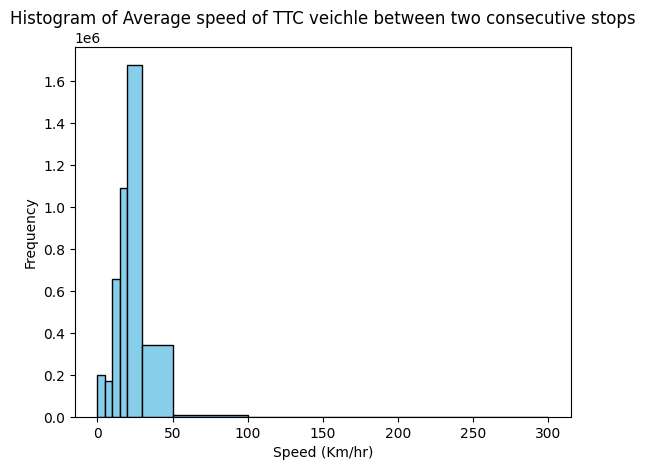

count   4148586.0000
mean         19.6407
std           8.1838
min           0.0038
25%          15.0642
50%          19.8204
75%          24.5787
max         189.1440
Name: Average_Speed_Km/hr, dtype: float64


In [244]:
# lastly lets check for trips that are going too fast or too slow between two consecutive stops

# first calculate average speed of transit veichle between two consecutive stops
# we will do this by dividing the distance between the previous stop and current stop (in what i beleive is meters) with time difference between previous stop departure time and 
# current stop arrival time (time_diff) in seconds and multiplying by 3.6 to get km/hr


stop_times["Average_Speed_Km/hr"] = stop_times["dist_diff"]/stop_times["time_diff"] * 3.6
speed_of_veichle = stop_times[["trip_id", "stop_id","shape_dist_traveled", "time_diff", "dist_diff", "Average_Speed_Km/hr"]]
display(speed_of_veichle)

# lets generate a distribution of veichle speed between two stops

plt.hist(speed_of_veichle["Average_Speed_Km/hr"], bins = [0,5,10,15,20,30,50,100,300], color='skyblue', edgecolor='black')

# Add labels and title
plt.title('Histogram of Average speed of TTC veichle between two consecutive stops')
plt.xlabel('Speed (Km/hr)')
plt.ylabel('Frequency')

# Display the plot
plt.show()

pd.set_option('display.float_format', '{:.4f}'.format)

print(speed_of_veichle["Average_Speed_Km/hr"].describe())

pd.reset_option('display.float_format')



In [245]:
# it makes sense that most veichles are going between 15 and 25 km/hr since most veichles in the TTC fleet would be bus and street cars which
# would travel such an average speed within highly urban areas that limit veichle speed

# the maximum speed is 189 km/hr which is suprising since that is much above the maximum speed of subway trains, steetcars and subways
# the minimum speed is 0.0038 km/hr which again is suprising since that is much below even walking speed (5 km/hr)

# lets display the trips where veichles are going less than an average of 5 km/hr 

display(speed_of_veichle[speed_of_veichle["Average_Speed_Km/hr"] <= 5])

pd.set_option('display.float_format', '{:.4f}'.format)
print(speed_of_veichle[speed_of_veichle["Average_Speed_Km/hr"] <= 5]["Average_Speed_Km/hr"].describe())
print(speed_of_veichle[speed_of_veichle["Average_Speed_Km/hr"] <= 5]["dist_diff"].describe())
pd.reset_option('display.float_format')

# so it seems that for most trips (180k of the 200k trips) containing stops where the veichle is moving less than an average of 5km/hr; the 
# consecutive stops of that trip are within 1-2 meters of each other

# lets view a few examples to see why
print("\n")
print("trips with consecutive stops within 2 meters of each other")
display(speed_of_veichle[speed_of_veichle["dist_diff"] <= 2])

,trip_id,stop_id,shape_dist_traveled,time_diff,dist_diff,Average_Speed_Km/hr
3333,100105020,7356,139.5000,107.0,139.5000,4.693458
7331,10022070,11178,9239.8400,207.0,172.6700,3.002957
7332,10022070,18660,9531.4400,391.0,291.6000,2.684808
7871,100241010,4163,776.9100,1170.0,776.9100,2.390492
7872,100241010,7148,1340.5300,838.0,563.6200,2.421279
...,...,...,...,...,...,...
4283989,133250424,13778,21.4800,74.0,0.6750,0.032838
4283990,133250424,13779,22.4015,90.0,0.9215,0.036860
4283991,133250424,13782,23.7012,129.0,1.2997,0.036271
4283992,133250424,13783,24.9180,121.0,1.2168,0.036202


count   200666.0000
mean         0.0945
std          0.5154
min          0.0038
25%          0.0220
50%          0.0281
75%          0.0360
max          4.9497
Name: Average_Speed_Km/hr, dtype: float64
count   200666.0000
mean         5.0214
std         38.0755
min          0.0146
25%          0.5619
50%          0.7524
75%          1.1334
max        776.9100
Name: dist_diff, dtype: float64


trips with consecutive stops within 2 meters of each other


,trip_id,stop_id,shape_dist_traveled,time_diff,dist_diff,Average_Speed_Km/hr
4078231,133243013,15601,1.7978,339.0,1.7978,0.019092
4078232,133243013,15589,2.0984,85.0,0.3006,0.012731
4078233,133243013,7980,2.5513,128.0,0.4529,0.012738
4078234,133243013,8522,2.9718,119.0,0.4205,0.012721
4078235,133243013,8811,3.3162,98.0,0.3444,0.012651
...,...,...,...,...,...,...
4283989,133250424,13778,21.4800,74.0,0.6750,0.032838
4283990,133250424,13779,22.4015,90.0,0.9215,0.036860
4283991,133250424,13782,23.7012,129.0,1.2997,0.036271
4283992,133250424,13783,24.9180,121.0,1.2168,0.036202


In [246]:
# lets merge the temporary speed_of_veichle data table with itself to get the previous stop for each current record
# then lets merge with stops to get the name and code for each stop_id
# this will make it easier to verify if this is an issue with the recorded distance metrics or an issue with trivial stops being included in the feed data

# first lets rewrite the stop_times dataframe to have incrementally generated sequence numbers instead of 
# randomly generated numbers that increase through the sequence

stop_times = stop_times.sort_values(
    ["trip_id", "stop_sequence"]
)

stop_times["stop_sequence"] = (
    stop_times.groupby("trip_id").cumcount() + 1
)

print("updated stop_sequence:")
display(stop_times.head(10))

updated stop_sequence:


,trip_id,arrival_time,departure_time,stop_id,stop_sequence,stop_headsign,pickup_type,drop_off_type,shape_dist_traveled,timepoint,arrival_time_seconds,departure_time_seconds,time_diff,dist_diff,Average_Speed_Km/hr
264665,1080,17:45:00,17:45:00,31495,1,53 STEELES EAST FINCH STN,0,0,0.00,1,63900,63900,NaN,NaN,NaN
264666,1080,17:46:58,17:46:58,2755,2,53 STEELES EAST FINCH STN,0,0,429.78,0,64018,64018,118.0,429.78,13.111932
264667,1080,17:49:13,17:49:13,10247,3,53 STEELES EAST FINCH STN,0,0,1032.50,0,64153,64153,135.0,602.72,16.072533
264668,1080,17:49:40,17:49:40,3973,4,53 STEELES EAST FINCH STN,0,0,1194.29,0,64180,64180,27.0,161.79,21.572000
264669,1080,17:50:29,17:50:29,8617,5,53 STEELES EAST FINCH STN,0,0,1483.61,0,64229,64229,49.0,289.32,21.256163
264670,1080,17:51:16,17:51:16,8926,6,53 STEELES EAST FINCH STN,0,0,1763.97,0,64276,64276,47.0,280.36,21.474383
264671,1080,17:52:04,17:52:04,5461,7,53 STEELES EAST FINCH STN,0,0,2051.25,0,64324,64324,48.0,287.28,21.546000
264672,1080,17:52:51,17:52:51,8516,8,53 STEELES EAST FINCH STN,0,0,2332.05,0,64371,64371,47.0,280.80,21.508085
264673,1080,17:53:34,17:53:34,963,9,53 STEELES EAST FINCH STN,0,0,2538.13,0,64414,64414,43.0,206.08,17.253209
264674,1080,17:55:15,17:55:15,43025,10,53 STEELES EAST FINCH STN,0,0,3076.43,0,64515,64515,101.0,538.30,19.186931


In [247]:
# we will produce a new table with the same function as stop_times with the more appropriate name of between_stop_metrics (instead of speed_of_veichle)
# we will merge with the stops table to get stop_name, stop_code, stop_lat and stop_lon for each stop

between_stop_metrics = stop_times.copy()

between_stop_metrics  = duckdb.sql("""
    SELECT
        btwn.trip_id,
        btwn.stop_sequence,
        btwn.stop_id,
        btwn.arrival_time, 
        btwn.departure_time,
        btwn.stop_headsign,
        btwn.shape_dist_traveled,
        btwn.time_diff,
        btwn.dist_diff,
        btwn."Average_Speed_Km/hr",                       
        stops.stop_name AS stop_name,
        stops.stop_code AS stop_code,
        stops.stop_lat AS stop_lat,
        stops.stop_lon AS stop_lon
                                                                                         
    FROM between_stop_metrics AS btwn
    JOIN stops AS stops
      ON btwn.stop_id = stops.stop_id
""").df()

between_stop_metrics = between_stop_metrics.sort_values(
    ["trip_id", "stop_sequence"]
)

display(between_stop_metrics)

,trip_id,stop_sequence,stop_id,arrival_time,departure_time,stop_headsign,shape_dist_traveled,time_diff,dist_diff,Average_Speed_Km/hr,stop_name,stop_code,stop_lat,stop_lon
1638400,1080,1,31495,17:45:00,17:45:00,53 STEELES EAST FINCH STN,0.0000,NaN,NaN,NaN,Morningside Ave at Passmore Ave - Amazon Fulfi...,16252,43.835793,-79.242093
1638401,1080,2,2755,17:46:58,17:46:58,53 STEELES EAST FINCH STN,429.7800,118.0,429.7800,13.111932,Steeles Ave East at Eastvale Rd,14379,43.838160,-79.245033
1638402,1080,3,10247,17:49:13,17:49:13,53 STEELES EAST FINCH STN,1032.5000,135.0,602.7200,16.072533,Steeles Ave East at Markham Rd West Side,11611,43.836512,-79.252190
1638403,1080,4,3973,17:49:40,17:49:40,53 STEELES EAST FINCH STN,1194.2900,27.0,161.7900,21.572000,Steeles Ave East at Marydale Ave,14603,43.836060,-79.254107
1638404,1080,5,8617,17:50:29,17:50:29,53 STEELES EAST FINCH STN,1483.6100,49.0,289.3200,21.256163,Steeles Ave East at Walkway to Irenemount Cres,11612,43.835243,-79.257531
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2440789,133251420,14,16298,25:37:31,25:37:31,None,8.0758,109.0,0.4207,0.013895,Stevenson Station - Westbound Platform,16298,43.743253,-79.586955
2440790,133251420,15,16296,25:39:00,25:39:00,None,8.4146,89.0,0.3388,0.013704,Albion Station - Westbound Platform,16296,43.740937,-79.589332
2440791,133251420,16,16294,25:41:14,25:41:14,None,8.9773,134.0,0.5627,0.015117,Martin Grove Station - Westbound Platform,16294,43.736771,-79.591921
2440792,133251420,17,16292,25:44:10,25:44:10,None,9.7161,176.0,0.7388,0.015112,Westmore Station - Westbound Platform,16292,43.734799,-79.600708


In [248]:
# we will merge between_stop_metrics with itself to get the previous stop information for each current stop of a specific trip using stop_sequence

between_stop_metrics = duckdb.sql("""
    SELECT
        curr.trip_id,
        curr.stop_sequence,
        curr.stop_id            AS curr_stop_id,
        curr.arrival_time       AS curr_arrival_time,
        curr.departure_time     AS curr_departure_time,
        curr.time_diff          AS curr_time_diff,
        curr.dist_diff          AS curr_dist_diff,
        curr."Average_Speed_Km/hr" AS "curr_Average_Speed_Km/hr",
        curr.stop_name AS curr_stop_name,
        curr.stop_code AS curr_stop_code,
        curr.stop_lat AS curr_stop_lat,
        curr.stop_lon AS curr_stop_lon,                          
        prev.stop_id            AS prev_stop_id,
        prev.departure_time     AS prev_departure_time,
        prev."Average_Speed_Km/hr" AS "prev_Average_Speed_Km_hr",                                             
        prev.stop_name AS prev_stop_name,
        prev.stop_code AS prev_stop_code,
        prev.stop_lat AS prev_stop_lat,
        prev.stop_lon AS prev_stop_lon, 

        curr.shape_dist_traveled AS curr_shape_dist_traveled,
        prev.shape_dist_traveled AS prev_shape_dist_traveled

    FROM between_stop_metrics AS curr
    JOIN between_stop_metrics AS prev
      ON curr.trip_id       = prev.trip_id
     AND curr.stop_sequence = prev.stop_sequence + 1
""").df()

between_stop_metrics = between_stop_metrics.sort_values(
    ["trip_id", "stop_sequence"]
)

display(between_stop_metrics)

,trip_id,stop_sequence,curr_stop_id,curr_arrival_time,curr_departure_time,curr_time_diff,curr_dist_diff,curr_Average_Speed_Km/hr,curr_stop_name,curr_stop_code,...,curr_stop_lon,prev_stop_id,prev_departure_time,prev_Average_Speed_Km_hr,prev_stop_name,prev_stop_code,prev_stop_lat,prev_stop_lon,curr_shape_dist_traveled,prev_shape_dist_traveled
3304196,1080,2,2755,17:46:58,17:46:58,118.0,429.7800,13.111932,Steeles Ave East at Eastvale Rd,14379,...,-79.245033,31495,17:45:00,NaN,Morningside Ave at Passmore Ave - Amazon Fulfi...,16252,43.835793,-79.242093,429.7800,0.0000
3304197,1080,3,10247,17:49:13,17:49:13,135.0,602.7200,16.072533,Steeles Ave East at Markham Rd West Side,11611,...,-79.252190,2755,17:46:58,13.111932,Steeles Ave East at Eastvale Rd,14379,43.838160,-79.245033,1032.5000,429.7800
3304198,1080,4,3973,17:49:40,17:49:40,27.0,161.7900,21.572000,Steeles Ave East at Marydale Ave,14603,...,-79.254107,10247,17:49:13,16.072533,Steeles Ave East at Markham Rd West Side,11611,43.836512,-79.252190,1194.2900,1032.5000
3304199,1080,5,8617,17:50:29,17:50:29,49.0,289.3200,21.256163,Steeles Ave East at Walkway to Irenemount Cres,11612,...,-79.257531,3973,17:49:40,21.572000,Steeles Ave East at Marydale Ave,14603,43.836060,-79.254107,1483.6100,1194.2900
3304200,1080,6,8926,17:51:16,17:51:16,47.0,280.3600,21.474383,Steeles Ave East at Shadlock St,11613,...,-79.260861,8617,17:50:29,21.256163,Steeles Ave East at Walkway to Irenemount Cres,11612,43.835243,-79.257531,1763.9700,1483.6100
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
259442,133251420,14,16298,25:37:31,25:37:31,109.0,0.4207,0.013895,Stevenson Station - Westbound Platform,16298,...,-79.586955,16300,25:35:42,0.013905,Mount Olive Station - Westbound Platform,16300,43.743335,-79.581793,8.0758,7.6551
259443,133251420,15,16296,25:39:00,25:39:00,89.0,0.3388,0.013704,Albion Station - Westbound Platform,16296,...,-79.589332,16298,25:37:31,0.013895,Stevenson Station - Westbound Platform,16298,43.743253,-79.586955,8.4146,8.0758
259444,133251420,16,16294,25:41:14,25:41:14,134.0,0.5627,0.015117,Martin Grove Station - Westbound Platform,16294,...,-79.591921,16296,25:39:00,0.013704,Albion Station - Westbound Platform,16296,43.740937,-79.589332,8.9773,8.4146
259445,133251420,17,16292,25:44:10,25:44:10,176.0,0.7388,0.015112,Westmore Station - Westbound Platform,16292,...,-79.600708,16294,25:41:14,0.015117,Martin Grove Station - Westbound Platform,16294,43.736771,-79.591921,9.7161,8.9773


In [249]:
# again, before we realized that for most trips (180k of the 200k trips) containing stops where the veichle is moving less than an average of 5km/hr; the 
# consecutive stops of that trip are within 1-2 meters of each other

# lets view a few examples to see why
print("trips with consecutive stops within 2 meters of each other")
display(between_stop_metrics[between_stop_metrics["curr_dist_diff"] <= 2])

# so it took 30 seconds to travel 0.1331 meters resulting in an average speed of 0.015972 Km/hr from Baycrest Hospital For Aged to Baycrest Hospital
# however the distance between the two stops (when inputting the latitudes and longitute for each stop) should be roughly 120 meters (if you walked
# between the two stops according to google maps)
# this means the bus should have roughly traveled 14.4 km/hr not 0.015972 km/hr

# it also took 86 seconds to travel 0.2615 meters to go from Wasdale Cres at Rajah St East Side to Wasdale Cres at Neptune Dr for a average speed
# of 0.0109465 km/hr however again according to google maps the distance is roughly 300 m

# ** Due to the previous observations, I believe records with shape_dist_traveled value of below 2, are recorded in kilometers instead of meters 
# which would explain why some average speed values are so incredibly low **

trips with consecutive stops within 2 meters of each other


,trip_id,stop_sequence,curr_stop_id,curr_arrival_time,curr_departure_time,curr_time_diff,curr_dist_diff,curr_Average_Speed_Km/hr,curr_stop_name,curr_stop_code,...,curr_stop_lon,prev_stop_id,prev_departure_time,prev_Average_Speed_Km_hr,prev_stop_name,prev_stop_code,prev_stop_lat,prev_stop_lon,curr_shape_dist_traveled,prev_shape_dist_traveled
585494,133243011,2,15607,08:43:29,08:43:29,30.0,0.1331,0.015972,Baycrest Hospital,15607,...,-79.433224,11641,08:42:59,NaN,Baycrest Home For Aged,11641,43.729774,-79.434176,0.1331,0.0000
585495,133243011,3,8070,08:44:30,08:44:30,61.0,0.2597,0.015327,Bathurst St at Bannockburn Ave,91,...,-79.432410,15607,08:43:29,0.015972,Baycrest Hospital,15607,43.729538,-79.433224,0.3928,0.1331
585496,133243011,4,2491,08:45:34,08:45:34,64.0,0.2706,0.015221,Hotspur Rd at Bathurst St West Side,6421,...,-79.433574,8070,08:44:30,0.015327,Bathurst St at Bannockburn Ave,91,43.731194,-79.432410,0.6634,0.3928
585497,133243011,5,7277,08:46:16,08:46:16,42.0,0.1779,0.015249,Hotspur Rd at Neptune Dr,6422,...,-79.435594,2491,08:45:34,0.015221,Hotspur Rd at Bathurst St West Side,6421,43.733132,-79.433574,0.8413,0.6634
585498,133243011,6,5643,08:47:13,08:47:13,57.0,0.2408,0.015208,Neptune Dr at Rajah St,6618,...,-79.438452,7277,08:46:16,0.015249,Hotspur Rd at Neptune Dr,6422,43.732503,-79.435594,1.0821,0.8413
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
259442,133251420,14,16298,25:37:31,25:37:31,109.0,0.4207,0.013895,Stevenson Station - Westbound Platform,16298,...,-79.586955,16300,25:35:42,0.013905,Mount Olive Station - Westbound Platform,16300,43.743335,-79.581793,8.0758,7.6551
259443,133251420,15,16296,25:39:00,25:39:00,89.0,0.3388,0.013704,Albion Station - Westbound Platform,16296,...,-79.589332,16298,25:37:31,0.013895,Stevenson Station - Westbound Platform,16298,43.743253,-79.586955,8.4146,8.0758
259444,133251420,16,16294,25:41:14,25:41:14,134.0,0.5627,0.015117,Martin Grove Station - Westbound Platform,16294,...,-79.591921,16296,25:39:00,0.013704,Albion Station - Westbound Platform,16296,43.740937,-79.589332,8.9773,8.4146
259445,133251420,17,16292,25:44:10,25:44:10,176.0,0.7388,0.015112,Westmore Station - Westbound Platform,16292,...,-79.600708,16294,25:41:14,0.015117,Martin Grove Station - Westbound Platform,16294,43.736771,-79.591921,9.7161,8.9773


In [250]:
# lets now look at the rest of the records (with too slow speeds) that had a distance of more than a few meters per stop

dist_2_plus = between_stop_metrics[(between_stop_metrics["curr_dist_diff"] > 5) & (between_stop_metrics["curr_Average_Speed_Km/hr"] <= 5)]
dist_2_plus = dist_2_plus.sort_values(["trip_id", "stop_sequence"])
display(dist_2_plus)

# first of all it looks like this issue only occurs to individual stops in a trip and not entire trips themselves
# the dist_diff values seem to be common distance values in meters (50 to 500m between stops-ish)

# in the first record of the dataframe the veichle is moving between St Clair West Station at Bay 4 to St Clair Ave West at Bathurst St West
# for a total distance of 494 meters taking 6-7 min for the trip; leaving an average speed of 4.606 km/hr. This is a big difference from
# the previous average speed of 39.5028 km/hr between the previous two stops. This is odd because according to google maps, it takes 4 min to 
# walk between the two stops and should take a car 1 min.

# however when consulting with ttc's trip planner, it seems that it roughly takes 8 min to travel between the two stops on the 512 bus
# trip planner: https://www.ttc.ca/trip-planner

# in the 90th record of the dataframe, the veichle is moving between Queens Quay west at Bay St East to Yonge St at Queens Quay East North
# for a total distance of 175.66 meters, taking 2-3 min for the trip, resulting in an average speed of 4.157 Km/hr. When consulting the TTC
# trip planner, yet again it takes 2-3 minutes to make this trip.

# it seems that alot of these trips are between stops in highly urban areas that are quite near each other; resulting in a low average speed
# between stops

# lets see a distribution of average speeds to see if there is any flagrant outliers
print(dist_2_plus["curr_Average_Speed_Km/hr"].describe())
print("\n")
print(dist_2_plus["curr_dist_diff"].describe())

# overall, feed data with a current distance difference over greater than 5 meters between stops and an average speed of less than 5 km/hr 
# is accurate and consistent to real world behavior

,trip_id,stop_sequence,curr_stop_id,curr_arrival_time,curr_departure_time,curr_time_diff,curr_dist_diff,curr_Average_Speed_Km/hr,curr_stop_name,curr_stop_code,...,curr_stop_lon,prev_stop_id,prev_departure_time,prev_Average_Speed_Km_hr,prev_stop_name,prev_stop_code,prev_stop_lat,prev_stop_lon,curr_shape_dist_traveled,prev_shape_dist_traveled
549390,68080,10,1339,21:02:17,21:02:17,386.0,493.91,4.606415,St Clair Ave West at Bathurst St West Side,14337,...,-79.418852,3862,20:55:51,39.502800,St Clair West Station at Bay 4,14780,43.684447,-79.415555,2687.18,2193.27
873521,144070,10,1339,19:08:17,19:08:17,386.0,493.91,4.606415,St Clair Ave West at Bathurst St West Side,14337,...,-79.418852,3862,19:01:51,39.502800,St Clair West Station at Bay 4,14780,43.684447,-79.415555,2687.18,2193.27
2237261,174070,33,4254,11:33:00,11:33:00,127.0,150.72,4.272378,Front St West at Bay St,1069,...,-79.378830,10226,11:30:53,7.684364,Yonge St at Front St West,1671,43.646785,-79.377161,7296.86,7146.14
167731,325020,2,7356,06:07:41,06:07:41,161.0,139.50,3.119255,Warden Ave at Steeles Ave East,10564,...,-79.324712,9618,06:05:00,NaN,Warden Loop at Steeles Ave East,13462,43.820970,-79.325087,139.50,0.00
3979949,401080,69,3729,18:19:00,18:19:00,90.0,97.54,3.901600,Don Mills Station at Bus Bay 11,14631,...,-79.346345,9279,18:17:30,19.807457,Sheppard Ave East at Parkway Forest Dr West Side,7226,43.775632,-79.345160,20147.85,20050.31
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3334158,133154070,4,6268,17:08:46,17:08:46,161.0,182.05,4.070683,Bay St at Adelaide St West North Side,231,...,-79.380752,8497,17:06:05,3.819972,Bay St at King St West,256,43.648532,-79.380116,509.40,327.35
3334159,133154070,5,5320,17:11:27,17:11:27,161.0,187.30,4.188075,Bay St at Queen St West,261,...,-79.381439,6268,17:08:46,4.070683,Bay St at Adelaide St West North Side,231,43.650085,-79.380752,696.70,509.40
3335171,133191010,47,139,05:54:12,05:54:12,437.0,438.11,3.609144,Bay St at Harbour St South Side - Ferry Docks ...,254,...,-79.377377,18789,05:46:55,13.807514,Bay St at Front St West South Side - Union Sta...,246,43.645484,-79.378997,12169.90,11731.79
3335172,133191010,48,7995,05:57:25,05:57:25,193.0,197.50,3.683938,Queens Quay West at Bay St East Side,1465,...,-79.375474,139,05:54:12,3.609144,Bay St at Harbour St South Side - Ferry Docks ...,254,43.641735,-79.377377,12367.40,12169.90


count    3312.000000
mean        4.016713
std         0.669491
min         1.790286
25%         3.678178
50%         4.000170
75%         4.602667
max         4.949673
Name: curr_Average_Speed_Km/hr, dtype: float64


count    3312.000000
mean      249.266253
std       164.837050
min        18.380000
25%       117.420000
50%       175.660000
75%       438.110000
max       776.910000
Name: curr_dist_diff, dtype: float64


In [251]:
# ********************************************************************************************************************************************** #

# Therefore when processing speed data; if the average speed is below 5 km/hr and have a curr_dist_diff < 5, we will assume the recorded 
# shape_dist_traveled measurement is in kilometers instead of meters and recalculate the average speed for such records

# and if the average speed is below 5 km/hr and has a curr_dist_diff > 5, we will assume the recorded average_speed is true to the real-life
# behavior of a TTC veichle moving in between two stops 
#(basically we assume the distance is correctly recorded in meters since a greater than 5 km distance between 2 stops is impossible)

# ********************************************************************************************************************************************** #

In [252]:
## now lets look at average speeds that are too high

# the fastest transit veichle in the TTC fleet are the subway trains which have a maximum of 88 Km/hr, https://www.ttc.ca/transparency-and-accountability/Operating-Statistics/operating-statistics-2016/toronto-rocket-subway-trains

# lets look for records with an average speed greater than 88 Km/hr
too_fast = between_stop_metrics[between_stop_metrics["curr_Average_Speed_Km/hr"] >= 88]
too_fast = too_fast.sort_values(["trip_id", "stop_sequence"])
display(too_fast)

# in record 3 of the dataframe, a veichle is going from staines rd at solstice dr to staines rd at hepatica st; a distance of 236 meters 
# (231.86 according to google maps) in 6 seconds giving an average speed of roughly 140 Km/hr. First of all these stops are situated in a 
# neighbourhood, so I doubt any veichle is going over 50/60 Km/hr and going between stops in a 6 second window seems quite unlikely to me.
# using ttc trip planner it apparently takes 1 minute for the bus to go between stops

# looking at another pair of stops in the same trip (record 7), a veichle is going from staines rd at warbler circle to staines rd at point
# rouge trial, a distance of 168 meters (140 meters in google maps), in 4 seconds giving an average speed of 151 km/hr. On TTC trip planner,
# it says it would take under 1 minute to go between stops however I highly doubt it would take 4 seconds

# looking at another trip (record 57), a veichle is going from jetliner rd at airport rd south side to pearson airport terminal 1; a distance of 
# 2.5 km, in 94 seconds, giving an average speed of 96 km/hr

# while in google maps it shows a distance of 1.3 km

# lets look at the distribution of curr_time_diff and curr_dist_diff in the too_fast dataframe
print(too_fast["curr_time_diff"].describe())
print("\n")
print(too_fast["curr_dist_diff"].describe())
print("\n")
print(too_fast["curr_Average_Speed_Km/hr"].describe())

# it seems that 50% of the data has time_diff values that are equal to or less than 16 seconds which to me is a red flag
# as a rough measure, we will impute the cur_average_speed to the median average_speed between stops of all stops in all trips to get a more
# realistic speed measure. Unfortunately there is no efficient way of verifying the real life time taken between stops for all records
# since this accounts for a low percentage of total data (500 or so records out of 4 million records), imputation won't affect the total 
# distribution of speeds between stops significantly 


,trip_id,stop_sequence,curr_stop_id,curr_arrival_time,curr_departure_time,curr_time_diff,curr_dist_diff,curr_Average_Speed_Km/hr,curr_stop_name,curr_stop_code,...,curr_stop_lon,prev_stop_id,prev_departure_time,prev_Average_Speed_Km_hr,prev_stop_name,prev_stop_code,prev_stop_lat,prev_stop_lon,curr_shape_dist_traveled,prev_shape_dist_traveled
552299,576010,4,10507,22:41:00,22:41:00,100.0,2513.94,90.501840,Pearson Airport Terminal 1 (Ground Level Colum...,14092,...,-79.611041,4105,22:39:20,42.889928,Jetliner Rd at Airport Rd South Side,15144,43.685321,-79.607296,13624.83,11110.89
1213994,679020,74,4030,06:46:14,06:46:14,7.0,239.78,123.315429,Staines Rd at Solstice Dr,14984,...,-79.231597,2757,06:46:07,80.698154,Staines Rd at Quietbrook Cres (North),14382,43.838700,-79.232300,26670.68,26430.90
1213995,679020,75,4031,06:46:20,06:46:20,6.0,235.51,141.306000,Staines Rd at Hepatica St,14985,...,-79.230163,4030,06:46:14,123.315429,Staines Rd at Solstice Dr,14984,43.836626,-79.231597,26906.19,26670.68
1213996,679020,76,4034,06:46:35,06:46:35,15.0,526.33,126.319200,Staines Rd at Boulderbrook Dr,14988,...,-79.224963,4031,06:46:20,141.306000,Staines Rd at Hepatica St,14985,43.834862,-79.230163,27432.52,26906.19
1213997,679020,77,6043,06:46:45,06:46:45,10.0,342.05,123.138000,Staines Rd at Seasons Dr South Side,14266,...,-79.223612,4034,06:46:35,126.319200,Staines Rd at Boulderbrook Dr,14988,43.833043,-79.224963,27774.57,27432.52
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2274833,132510010,3,1659,10:28:09,10:28:09,53.0,1297.53,88.134113,Sheppard Ave East at Meadowvale Rd West Side,11670,...,-79.171598,5556,10:27:16,99.636750,Park Rd (Zoo) at Kirkhams Rd East Side,9672,43.818130,-79.175121,1740.36,442.83
196963,132602010,4,10507,22:51:00,22:51:00,100.0,2513.94,90.501840,Pearson Airport Terminal 1 (Ground Level Colum...,14092,...,-79.611041,4105,22:49:20,42.889928,Jetliner Rd at Airport Rd South Side,15144,43.685321,-79.607296,13624.83,11110.89
4010446,132808080,4,10507,08:02:00,08:02:00,94.0,2513.94,96.278553,Pearson Airport Terminal 1 (Ground Level Colum...,14092,...,-79.611041,4105,08:00:26,45.585197,Jetliner Rd at Airport Rd South Side,15144,43.685321,-79.607296,13624.83,11110.89
1912106,132881080,4,10507,06:52:00,06:52:00,94.0,2513.94,96.278553,Pearson Airport Terminal 1 (Ground Level Colum...,14092,...,-79.611041,4105,06:50:26,45.585197,Jetliner Rd at Airport Rd South Side,15144,43.685321,-79.607296,13624.83,11110.89


count    1061.000000
mean       46.572102
std        42.772409
min         4.000000
25%        10.000000
50%        16.000000
75%       100.000000
max       100.000000
Name: curr_time_diff, dtype: float64


count    1061.000000
mean     1225.731310
std      1052.579378
min       168.360000
25%       342.050000
50%       442.830000
75%      2513.940000
max      2513.940000
Name: curr_dist_diff, dtype: float64


count    1061.000000
mean      108.657216
std        19.787824
min        88.134113
25%        90.501840
50%        99.636750
75%       125.287200
max       189.144000
Name: curr_Average_Speed_Km/hr, dtype: float64


In [253]:
# lets now focus on the records with time_diff values of greater than 16 seconds (most records have roughly 100+ second time differences between
# stops)

too_fast_enough_time = between_stop_metrics[(between_stop_metrics["curr_Average_Speed_Km/hr"] >= 88) & (between_stop_metrics["curr_time_diff"] > 16)]
too_fast_enough_time = too_fast_enough_time.sort_values(["trip_id", "stop_sequence"])
display(too_fast_enough_time)

print(too_fast_enough_time["curr_stop_name"].value_counts())
print("\n")
print(too_fast_enough_time["curr_stop_code"].value_counts())

# it looks like all of these trips are going to two stops (pearson airport terminal or sheppard ave east at meadowvale rd)

print("\n")
print(too_fast_enough_time["curr_Average_Speed_Km/hr"].describe())

# and it looks like these veichles are going between 88 and 96 Km/hr

print("\n")
print(too_fast_enough_time["curr_time_diff"].describe())
print("\n")
print(too_fast_enough_time["curr_dist_diff"].describe())

# lastly it looks like these veichles are roughly taking 90 to 100 seconds to go between two stops with a distance of roughly 2.5 km

# the time between stops is reasonable, so I hypothesize that the distances between stops are being incorrectly reported
# lets merge the too_fast_enough_time frame with trips to get the route_id for each record

,trip_id,stop_sequence,curr_stop_id,curr_arrival_time,curr_departure_time,curr_time_diff,curr_dist_diff,curr_Average_Speed_Km/hr,curr_stop_name,curr_stop_code,...,curr_stop_lon,prev_stop_id,prev_departure_time,prev_Average_Speed_Km_hr,prev_stop_name,prev_stop_code,prev_stop_lat,prev_stop_lon,curr_shape_dist_traveled,prev_shape_dist_traveled
552299,576010,4,10507,22:41:00,22:41:00,100.0,2513.94,90.501840,Pearson Airport Terminal 1 (Ground Level Colum...,14092,...,-79.611041,4105,22:39:20,42.889928,Jetliner Rd at Airport Rd South Side,15144,43.685321,-79.607296,13624.83,11110.89
878418,1174010,4,10507,14:40:00,14:40:00,100.0,2513.94,90.501840,Pearson Airport Terminal 1 (Ground Level Colum...,14092,...,-79.611041,4105,14:38:20,42.889928,Jetliner Rd at Airport Rd South Side,15144,43.685321,-79.607296,13624.83,11110.89
554272,1223070,4,10507,17:20:00,17:20:00,100.0,2513.94,90.501840,Pearson Airport Terminal 1 (Ground Level Colum...,14092,...,-79.611041,4105,17:18:20,42.889928,Jetliner Rd at Airport Rd South Side,15144,43.685321,-79.607296,13624.83,11110.89
2239665,1265080,4,10507,12:32:00,12:32:00,100.0,2513.94,90.501840,Pearson Airport Terminal 1 (Ground Level Colum...,14092,...,-79.611041,4105,12:30:20,42.889928,Jetliner Rd at Airport Rd South Side,15144,43.685321,-79.607296,13624.83,11110.89
2241113,1310080,4,10507,18:40:00,18:40:00,100.0,2513.94,90.501840,Pearson Airport Terminal 1 (Ground Level Colum...,14092,...,-79.611041,4105,18:38:20,42.889928,Jetliner Rd at Airport Rd South Side,15144,43.685321,-79.607296,13624.83,11110.89
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2274833,132510010,3,1659,10:28:09,10:28:09,53.0,1297.53,88.134113,Sheppard Ave East at Meadowvale Rd West Side,11670,...,-79.171598,5556,10:27:16,99.636750,Park Rd (Zoo) at Kirkhams Rd East Side,9672,43.818130,-79.175121,1740.36,442.83
196963,132602010,4,10507,22:51:00,22:51:00,100.0,2513.94,90.501840,Pearson Airport Terminal 1 (Ground Level Colum...,14092,...,-79.611041,4105,22:49:20,42.889928,Jetliner Rd at Airport Rd South Side,15144,43.685321,-79.607296,13624.83,11110.89
4010446,132808080,4,10507,08:02:00,08:02:00,94.0,2513.94,96.278553,Pearson Airport Terminal 1 (Ground Level Colum...,14092,...,-79.611041,4105,08:00:26,45.585197,Jetliner Rd at Airport Rd South Side,15144,43.685321,-79.607296,13624.83,11110.89
1912106,132881080,4,10507,06:52:00,06:52:00,94.0,2513.94,96.278553,Pearson Airport Terminal 1 (Ground Level Colum...,14092,...,-79.611041,4105,06:50:26,45.585197,Jetliner Rd at Airport Rd South Side,15144,43.685321,-79.607296,13624.83,11110.89


curr_stop_name
Pearson Airport Terminal 1 (Ground Level Column R4)    416
Sheppard Ave East at Meadowvale Rd West Side            37
Name: count, dtype: int64


curr_stop_code
14092    416
11670     37
Name: count, dtype: int64


count    453.000000
mean      91.484689
std        2.398030
min       88.134113
25%       90.501840
50%       90.501840
75%       90.501840
max       96.278553
Name: curr_Average_Speed_Km/hr, dtype: float64


count    453.000000
mean      94.988962
std       12.967023
min       50.000000
25%       94.000000
50%      100.000000
75%      100.000000
max      100.000000
Name: curr_time_diff, dtype: float64


count     453.000000
mean     2414.586424
std       333.510254
min      1297.530000
25%      2513.940000
50%      2513.940000
75%      2513.940000
max      2513.940000
Name: curr_dist_diff, dtype: float64


In [254]:
too_fast_enough_time = between_stop_metrics.copy()

too_fast_enough_time = duckdb.sql("""
    SELECT
        tfet.*,
        trips.route_id AS route_id,
        trips.trip_headsign AS trip_headsign
    FROM too_fast_enough_time AS tfet
    JOIN trips AS trips
      ON tfet.trip_id = trips.trip_id
""").df()

too_fast_enough_time = too_fast_enough_time.sort_values(
    ["trip_id", "stop_sequence"]
)

too_fast_enough_time = too_fast_enough_time[(too_fast_enough_time["curr_Average_Speed_Km/hr"] >= 88) & (too_fast_enough_time["curr_time_diff"] > 16)]
too_fast_enough_time = too_fast_enough_time.sort_values(["trip_id", "stop_sequence"])
display(too_fast_enough_time)

print(too_fast_enough_time["route_id"].value_counts())

,trip_id,stop_sequence,curr_stop_id,curr_arrival_time,curr_departure_time,curr_time_diff,curr_dist_diff,curr_Average_Speed_Km/hr,curr_stop_name,curr_stop_code,...,prev_departure_time,prev_Average_Speed_Km_hr,prev_stop_name,prev_stop_code,prev_stop_lat,prev_stop_lon,curr_shape_dist_traveled,prev_shape_dist_traveled,route_id,trip_headsign
326285,576010,4,10507,22:41:00,22:41:00,100.0,2513.94,90.501840,Pearson Airport Terminal 1 (Ground Level Colum...,14092,...,22:39:20,42.889928,Jetliner Rd at Airport Rd South Side,15144,43.685321,-79.607296,13624.83,11110.89,900,North - 900 Airport Express towards Pearson Ai...
344866,1174010,4,10507,14:40:00,14:40:00,100.0,2513.94,90.501840,Pearson Airport Terminal 1 (Ground Level Colum...,14092,...,14:38:20,42.889928,Jetliner Rd at Airport Rd South Side,15144,43.685321,-79.607296,13624.83,11110.89,900,North - 900 Airport Express towards Pearson Ai...
346117,1223070,4,10507,17:20:00,17:20:00,100.0,2513.94,90.501840,Pearson Airport Terminal 1 (Ground Level Colum...,14092,...,17:18:20,42.889928,Jetliner Rd at Airport Rd South Side,15144,43.685321,-79.607296,13624.83,11110.89,900,North - 900 Airport Express towards Pearson Ai...
347399,1265080,4,10507,12:32:00,12:32:00,100.0,2513.94,90.501840,Pearson Airport Terminal 1 (Ground Level Colum...,14092,...,12:30:20,42.889928,Jetliner Rd at Airport Rd South Side,15144,43.685321,-79.607296,13624.83,11110.89,900,North - 900 Airport Express towards Pearson Ai...
348847,1310080,4,10507,18:40:00,18:40:00,100.0,2513.94,90.501840,Pearson Airport Terminal 1 (Ground Level Colum...,14092,...,18:38:20,42.889928,Jetliner Rd at Airport Rd South Side,15144,43.685321,-79.607296,13624.83,11110.89,900,North - 900 Airport Express towards Pearson Ai...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3266488,132510010,3,1659,10:28:09,10:28:09,53.0,1297.53,88.134113,Sheppard Ave East at Meadowvale Rd West Side,11670,...,10:27:16,99.636750,Park Rd (Zoo) at Kirkhams Rd East Side,9672,43.818130,-79.175121,1740.36,442.83,85,West - 85 Sheppard East towards Don Mills Station
3269079,132602010,4,10507,22:51:00,22:51:00,100.0,2513.94,90.501840,Pearson Airport Terminal 1 (Ground Level Colum...,14092,...,22:49:20,42.889928,Jetliner Rd at Airport Rd South Side,15144,43.685321,-79.607296,13624.83,11110.89,900,North - 900 Airport Express towards Pearson Ai...
3274767,132808080,4,10507,08:02:00,08:02:00,94.0,2513.94,96.278553,Pearson Airport Terminal 1 (Ground Level Colum...,14092,...,08:00:26,45.585197,Jetliner Rd at Airport Rd South Side,15144,43.685321,-79.607296,13624.83,11110.89,900,North - 900 Airport Express towards Pearson Ai...
3276713,132881080,4,10507,06:52:00,06:52:00,94.0,2513.94,96.278553,Pearson Airport Terminal 1 (Ground Level Colum...,14092,...,06:50:26,45.585197,Jetliner Rd at Airport Rd South Side,15144,43.685321,-79.607296,13624.83,11110.89,900,North - 900 Airport Express towards Pearson Ai...


route_id
900    416
85      37
Name: count, dtype: int64


In [255]:
# for route 900, the distance between jetliner rd at airport rd south side to pearson airport terminal 1 is 1.26 km on google maps
# while this may not be an entirely accurate estimate of distance, I beleive it is a more probable estimate of the distance between
# the two stops

# for route 85, the distance between park rd at kirkhams rd east side and sheppard ave east at meadowvale rd west side is roughly 1.297 km 
# (1.26 km in google maps); however in ttc trip planner it takes 3 minutes to travel between stops
# this is a more reasonable estimate of time between stops than 53 seconds


In [256]:
# lets create a new column in stop_times called "updated_avg_speed" to include changes identified previously

# if speed is too low (< 5 Km/hr), update avg_speed accordingly (either convert distance travelled to km or keep as is)
# if speed is too high (>= 88 Km/hr) and time_diff is too low <= 16 seconds(), impute with median speed
# if speed is too high (>= 88 Km/hr) and time_diff is larger than 16 seconds, change distance for route 900 (stop_code 14092) to 1.26km (1260m) and 
# route 85 (stop_code = 11670) to 3 minutes (180 seconds)

def func(avg_speed, curr_dist_diff, curr_time_diff, curr_stop_code):
    if (avg_speed < 5) and (curr_dist_diff < 5):
        curr_dist_diff = curr_dist_diff * 1000
    elif (avg_speed >= 88) and (curr_time_diff <= 16):
        return 19.82
    elif (avg_speed >= 88) and (curr_time_diff > 16):
        if (curr_stop_code == 14092):
            curr_dist_diff = 1260
        elif (curr_stop_code == 11670):
            curr_time_diff = 180

    avg_speed = (curr_dist_diff / curr_time_diff) * 3.6 
    return avg_speed


stop_times['Updated_Average_Speed_Km/hr'] = stop_times.apply(
    lambda row: func(
        row['Average_Speed_Km/hr'],
        row['dist_diff'],
        row['time_diff'],
        row['shape_dist_traveled']
    ),axis=1
)

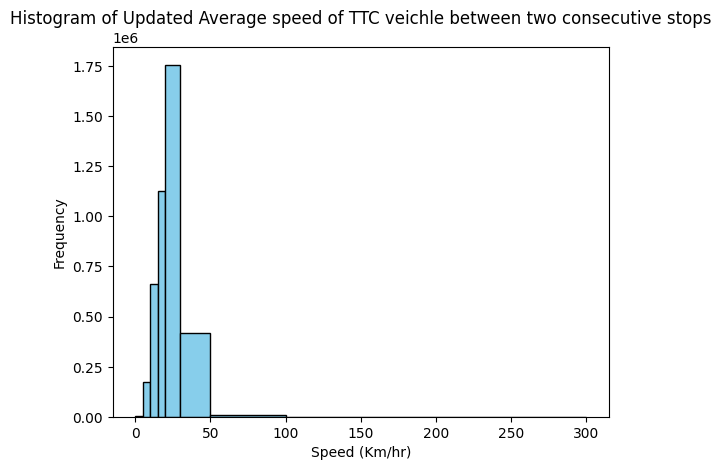

count   4148586.0000
mean         20.9880
std           7.3067
min           1.7903
25%          15.9371
50%          20.4127
75%          25.2041
max         292.7760
Name: Updated_Average_Speed_Km/hr, dtype: float64


In [257]:
# lets view the updated distribution of updated average speeds between stops of ttc veichles

plt.hist(stop_times["Updated_Average_Speed_Km/hr"], bins = [0,5,10,15,20,30,50,100,300], color='skyblue', edgecolor='black')

# Add labels and title
plt.title('Histogram of Updated Average speed of TTC veichle between two consecutive stops')
plt.xlabel('Speed (Km/hr)')
plt.ylabel('Frequency')

# Display the plot
plt.show()

pd.set_option('display.float_format', '{:.4f}'.format)

print(stop_times["Updated_Average_Speed_Km/hr"].describe())

pd.reset_option('display.float_format')



In [ ]:
# overall the distribution of updated average speed of TTC veichles between consecutive stops makes more sense (high volume of trip speeds between
# 10-50 Km/hr)

# some trips still have issues with the time taken to travel metrics and distances metrics 
# (below we see records taking 4 seconds to travel 0.11 meters or 60 seconds to travel a few meters, this is probably an issue 
# with the recording of both time and distance values)

# for ease of work, lets impute these rows with the median average speed

display(stop_times[stop_times["Updated_Average_Speed_Km/hr"] > 100])

stop_times.loc[
    stop_times["Updated_Average_Speed_Km/hr"] > 100,
    "Updated_Average_Speed_Km/hr"
] = 19.82

,trip_id,arrival_time,departure_time,stop_id,stop_sequence,stop_headsign,pickup_type,drop_off_type,shape_dist_traveled,timepoint,arrival_time_seconds,departure_time_seconds,time_diff,dist_diff,Average_Speed_Km/hr,Updated_Average_Speed_Km/hr
4079185,133243041,10:25:50,10:25:50,43160,16,NaN,0,0,6.4975,1,37550,37550,4.0,0.1123,0.101070,101.070000
4079333,133243042,11:40:50,11:40:50,43160,16,NaN,0,0,6.4975,1,42050,42050,4.0,0.1123,0.101070,101.070000
4079302,133243043,12:55:50,12:55:50,43160,16,NaN,0,0,6.4975,1,46550,46550,4.0,0.1123,0.101070,101.070000
4079271,133243044,14:40:50,14:40:50,43160,16,NaN,0,0,6.4975,1,52850,52850,4.0,0.1123,0.101070,101.070000
4079216,133243045,15:55:50,15:55:50,43160,16,NaN,0,0,6.4975,1,57350,57350,4.0,0.1123,0.101070,101.070000
4079247,133243046,17:10:50,17:10:50,43160,16,NaN,0,0,6.4975,1,61850,61850,4.0,0.1123,0.101070,101.070000
4229111,133244226,05:53:55,05:53:55,13851,2,NaN,0,0,4.0122,1,21235,21235,60.0,4.0122,0.240732,240.732000
4240915,133246345,13:00:55,13:00:55,14947,31,NaN,0,0,26.1379,1,46855,46855,59.0,2.6095,0.159224,159.223729
4253264,133246574,11:52:50,11:52:50,14948,31,NaN,0,0,26.1379,1,42770,42770,15.0,1.2199,0.292776,292.776000


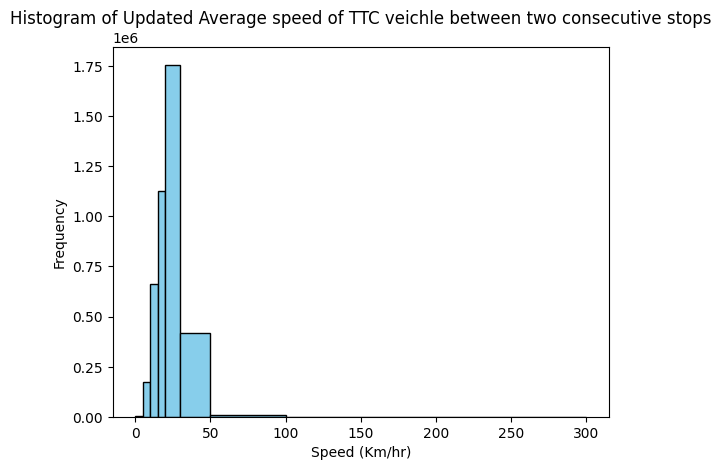

count   4148586.0000
mean         20.9878
std           7.3037
min           1.7903
25%          15.9371
50%          20.4127
75%          25.2041
max          99.5400
Name: Updated_Average_Speed_Km/hr, dtype: float64


In [262]:
# lets view the updated distribution of updated average speeds between stops of ttc veichles

plt.hist(stop_times["Updated_Average_Speed_Km/hr"], bins = [0,5,10,15,20,30,50,100,300], color='skyblue', edgecolor='black')

# Add labels and title
plt.title('Histogram of Updated Average speed of TTC veichle between two consecutive stops')
plt.xlabel('Speed (Km/hr)')
plt.ylabel('Frequency')

# Display the plot
plt.show()

pd.set_option('display.float_format', '{:.4f}'.format)

print(stop_times["Updated_Average_Speed_Km/hr"].describe())

pd.reset_option('display.float_format')

### Data Processing

In [ ]:
# 